# RQ1 — Payment Gap Analysis
**Research Question:** What diagnosis groups, hospital types, geographic regions, and ownership types are associated with the largest and most persistent gaps between billed charges and Medicare payments?

---
### Sections
1. Setup & Load Data
2. Overall Payment Gap Summary
3. Payment Gap by DRG (Top / Bottom)
4. DRG Severity vs Payment Gap
5. Payment Gap Trend Over Time (2017–2023)
6. Payment Gap by Ownership Type
7. Payment Gap by Geography (RUCA)
8. State-Level Payment Gap
9. Ownership × Geography Interaction
10. Top DRGs × Ownership Breakdown
11. RQ1 Summary

## 1. Setup & Load Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']  = 110
plt.rcParams['font.size']   = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Colour palette (consistent across all charts) ──────────────────────────
BLUE   = '#1565C0'
ORANGE = '#EF6C00'
GREEN  = '#2E7D32'
RED    = '#C62828'
PURPLE = '#6A1B9A'
GOLD   = '#F9A825'

OWN_PALETTE  = {'For-Profit': BLUE, 'Non-Profit': ORANGE, 'Government': GREEN}
RUCA_PALETTE = {'Metropolitan': BLUE, 'Micropolitan': ORANGE, 'Small Town': GOLD, 'Rural': GREEN}
RUCA_ORDER   = ['Metropolitan', 'Micropolitan', 'Small Town', 'Rural']

In [25]:
BASE_DIR      = Path('..')
PROCESSED_DIR = BASE_DIR / 'Data' / 'Processed_Data'

df = pd.read_parquet(PROCESSED_DIR / 'df_medidata.parquet')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Years : {sorted(df["Data_Year"].unique())}')
print(f'States: {df["Rndrng_Prvdr_State_Abrvtn"].nunique()} unique')

Loaded: 1,178,407 rows × 20 columns
Years : [2017, 2018, 2019, 2020, 2021, 2022, 2023]
States: 51 unique


In [26]:
# ── Ensure all derived features exist  ─────────────────────────
if 'Payment_Gap' not in df.columns:
    df['Payment_Gap'] = df['Avg_Submtd_Cvrd_Chrg'] - df['Avg_Mdcr_Pymt_Amt']

if 'Payment_Ratio' not in df.columns:
    df['Payment_Ratio'] = df['Avg_Mdcr_Pymt_Amt'] / df['Avg_Submtd_Cvrd_Chrg']

if 'payment_gap_per_discharge' not in df.columns:
    df['payment_gap_per_discharge'] = df['Payment_Gap'] / df['Tot_Dschrgs']

# ── RUCA grouping ──────────────────────────────────────────────────────────
def map_ruca_group(v):
    if pd.isna(v) or v == 99.0:           return 'Unknown'
    if v in [1.0,1.1,2.0,2.1,3.0]:       return 'Metropolitan'
    if v in [4.0,4.1,5.0,6.0]:           return 'Micropolitan'
    if v in [7.0,7.1,7.2,8.0,8.2,9.0]:   return 'Small Town'
    return 'Rural'

if 'RUCA_Group' not in df.columns:
    df['RUCA_Group'] = df['Rndrng_Prvdr_RUCA'].apply(map_ruca_group)

# ── Ownership label ────────────────────────────────────────────────────────
if 'Ownership_Type' not in df.columns:
    own_map = {
        1:'Non-Profit', 2:'Non-Profit', 3:'Non-Profit',
        4:'For-Profit', 5:'For-Profit', 6:'For-Profit',
        7:'Government', 8:'Government', 9:'Government', 10:'Government'
    }
    df['Ownership_Type'] = df['GNRL_CNTL_TYPE_CD'].map(own_map).fillna('Unknown')

# ── Short DRG label for charts ─────────────────────────────────────────────
df['DRG_Label'] = df['DRG_Cd'].astype(str) + ' – ' + df['DRG_Desc'].str[:45]

# ── Working subsets ────────────────────────────────────────────────────────
df_own  = df[df['Ownership_Type'].isin(['For-Profit','Non-Profit','Government'])].copy()
df_geo  = df[df['RUCA_Group'] != 'Unknown'].copy()

print('Feature check complete.')
print(f"  Payment_Gap   : min={df['Payment_Gap'].min():,.0f}  median={df['Payment_Gap'].median():,.0f}  max={df['Payment_Gap'].max():,.0f}")
print(f"  Payment_Ratio : min={df['Payment_Ratio'].min():.3f}  median={df['Payment_Ratio'].median():.3f}  max={df['Payment_Ratio'].max():.3f}")

Feature check complete.
  Payment_Gap   : min=-107,877  median=38,710  max=9,667,454
  Payment_Ratio : min=0.000  median=0.196  max=8.149


## 2. Overall Payment Gap Summary

In [27]:
# ── Headline numbers ───────────────────────────────────────────────────────
total_billed   = df['Avg_Submtd_Cvrd_Chrg'].median()
total_paid     = df['Avg_Mdcr_Pymt_Amt'].median()
median_gap     = df['Payment_Gap'].median()
median_ratio   = df['Payment_Ratio'].median()
median_gap_dis = df['payment_gap_per_discharge'].median()
pct_negative   = (df['Payment_Gap'] < 0).mean() * 100

print('=' * 55)
print('  RQ1 — OVERALL PAYMENT GAP SUMMARY')
print('=' * 55)
print(f'  Median billed charge       : ${total_billed:>12,.0f}')
print(f'  Median Medicare payment    : ${total_paid:>12,.0f}')
print(f'  Median payment gap         : ${median_gap:>12,.0f}')
print(f'  Median payment ratio       :  {median_ratio:>11.3f}  ({median_ratio*100:.1f}¢ per $1 billed)')
print(f'  Median gap per discharge   : ${median_gap_dis:>12,.0f}')
print(f'  Records w/ negative gap    :  {pct_negative:.2f}%  (CMS cost-outlier payments)')
print('=' * 55)

  RQ1 — OVERALL PAYMENT GAP SUMMARY
  Median billed charge       : $      48,566
  Median Medicare payment    : $       9,315
  Median payment gap         : $      38,710
  Median payment ratio       :        0.196  (19.6¢ per $1 billed)
  Median gap per discharge   : $       1,636
  Records w/ negative gap    :  0.13%  (CMS cost-outlier payments)


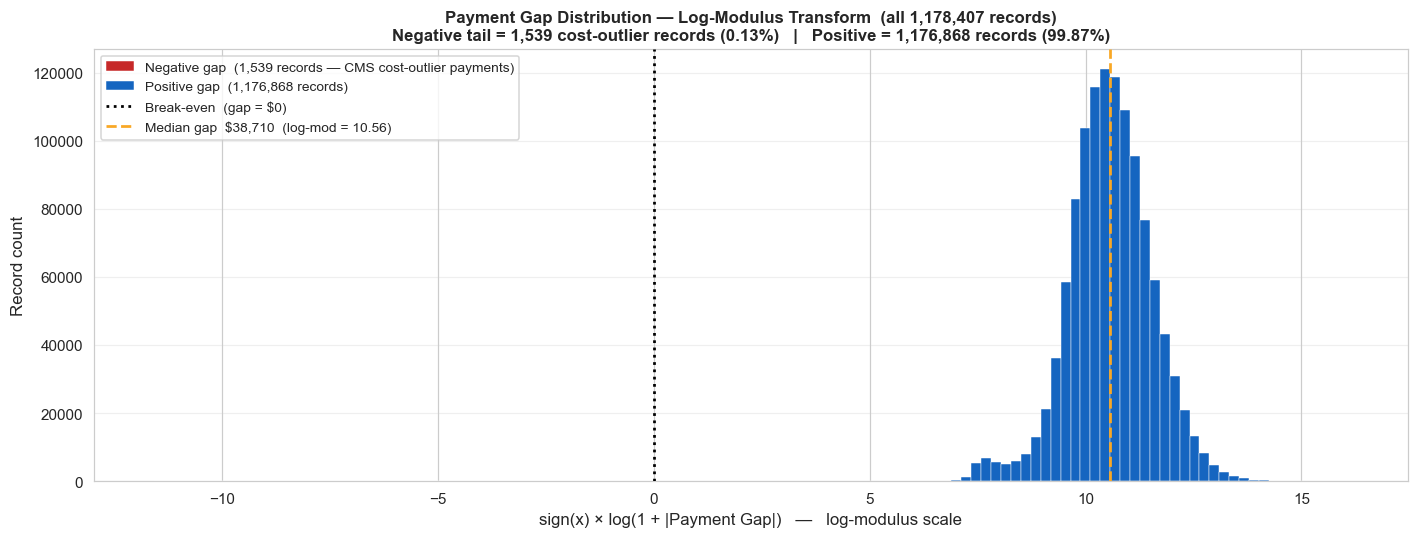

Figure 1a saved.
  Negative gap records : 1,539  (0.131%)
  Positive gap records : 1,176,868  (99.869%)
  Median payment gap   : $38,710


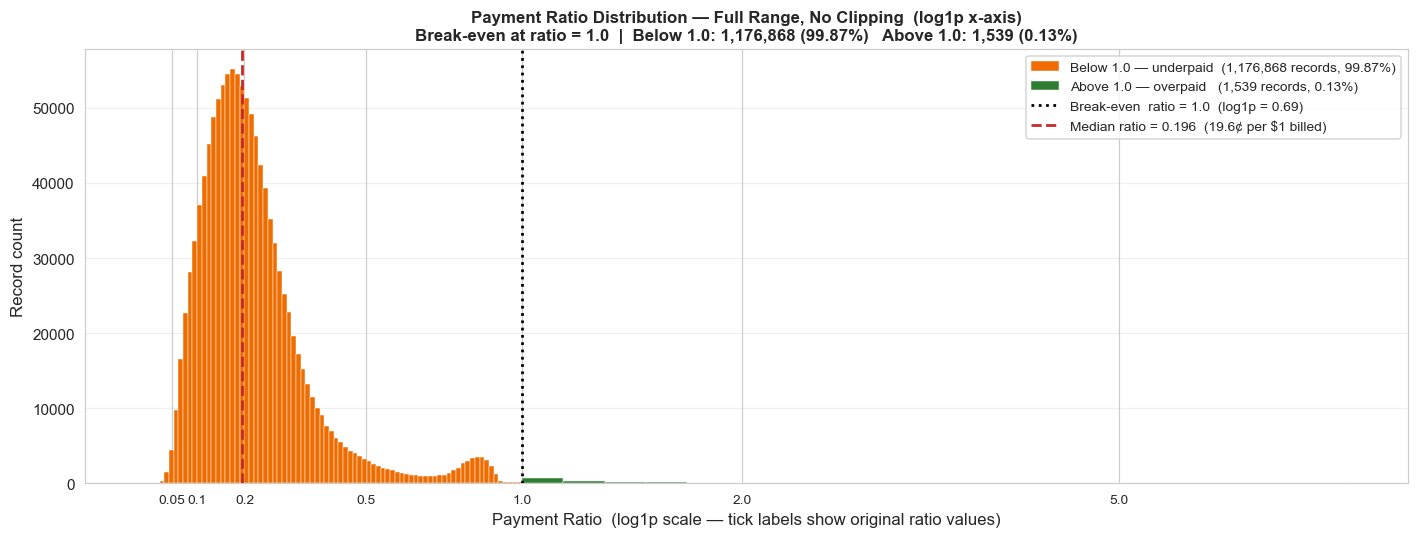

Figure 1b saved.
  Records below 1.0 (underpaid) : 1,176,868  (99.869%)
  Records above 1.0 (overpaid)  : 1,539  (0.131%)
  Median payment ratio           : 0.1957
  Max payment ratio              : 8.15


In [28]:
# ── Chart 1: Payment Gap — Log-Modulus, dual-region binning ───────────────
gap       = df['Payment_Gap']
log_mod   = np.sign(gap) * np.log1p(np.abs(gap))
neg_vals  = log_mod[log_mod < 0]
pos_vals  = log_mod[log_mod > 0]
n_neg     = len(neg_vals)
n_pos     = len(pos_vals)
median_lm = float(np.sign(gap.median()) * np.log1p(abs(gap.median())))

# Build bin edges independently per side so both tails are clearly visible
# Negative side: 30 bins across its own range
# Positive side: 70 bins across its own range
neg_edges = np.linspace(neg_vals.min(), 0, 31)        # 30 negative bins
pos_edges = np.linspace(0, pos_vals.max(), 71)         # 70 positive bins
all_edges = np.concatenate([neg_edges, pos_edges[1:]]) # merge, drop duplicate 0

fig, ax = plt.subplots(figsize=(13, 5))

# Plot each side in a different colour so the minority tail is immediately visible
ax.hist(neg_vals, bins=neg_edges, color=RED,  edgecolor='white', linewidth=0.3,
        label=f'Negative gap  ({n_neg:,} records — CMS cost-outlier payments)', zorder=3)
ax.hist(pos_vals, bins=pos_edges, color=BLUE, edgecolor='white', linewidth=0.3,
        label=f'Positive gap  ({n_pos:,} records)', zorder=2)

ax.axvline(0,         color='black', linestyle=':',  linewidth=1.8,
           label='Break-even  (gap = $0)', zorder=4)
ax.axvline(median_lm, color=GOLD,    linestyle='--', linewidth=1.8,
           label=f'Median gap  ${gap.median():,.0f}  (log-mod = {median_lm:.2f})', zorder=4)

ax.set_xlabel('sign(x) × log(1 + |Payment Gap|)   —   log-modulus scale', fontsize=11)
ax.set_ylabel('Record count', fontsize=11)
ax.set_title(
    f'Payment Gap Distribution — Log-Modulus Transform  (all {len(gap):,} records)\n'
    f'Negative tail = {n_neg:,} cost-outlier records ({n_neg/len(gap)*100:.2f}%)   |   '
    f'Positive = {n_pos:,} records ({n_pos/len(gap)*100:.2f}%)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
#plt.savefig('rq1_fig1a_gap_distribution_logmod.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 1a saved.')
print(f'  Negative gap records : {n_neg:,}  ({n_neg/len(gap)*100:.3f}%)')
print(f'  Positive gap records : {n_pos:,}  ({n_pos/len(gap)*100:.3f}%)')
print(f'  Median payment gap   : ${gap.median():,.0f}')

# ── Chart 2: Payment Ratio — Full range, dual-region binning ───────────────
ratio     = df['Payment_Ratio']
log_ratio = np.log1p(ratio)
log_break = np.log1p(1.0)
log_med   = np.log1p(ratio.median())

below   = log_ratio[log_ratio <  log_break]
above   = log_ratio[log_ratio >= log_break]
n_below = len(below)
n_above = len(above)

# Below break-even: 80 bins  |  Above break-even: 20 bins
below_edges = np.linspace(below.min(), log_break, 81)
above_edges = np.linspace(log_break,  above.max(), 21)

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(below, bins=below_edges, color=ORANGE, edgecolor='white', linewidth=0.3,
        label=f'Below 1.0 — underpaid  ({n_below:,} records, {n_below/len(ratio)*100:.2f}%)',
        zorder=2)
ax.hist(above, bins=above_edges, color=GREEN,  edgecolor='white', linewidth=0.3,
        label=f'Above 1.0 — overpaid   ({n_above:,} records, {n_above/len(ratio)*100:.2f}%)',
        zorder=3)

ax.axvline(log_break, color='black', linestyle=':',  linewidth=1.8,
           label=f'Break-even  ratio = 1.0  (log1p = {log_break:.2f})', zorder=4)
ax.axvline(log_med,   color=RED,     linestyle='--', linewidth=1.8,
           label=f'Median ratio = {ratio.median():.3f}  ({ratio.median()*100:.1f}¢ per $1 billed)',
           zorder=4)

# x-tick labels in original ratio scale for readability
tick_ratios = [0.05, 0.10, 0.20, 0.50, 1.0, 2.0, 5.0]
ax.set_xticks([np.log1p(t) for t in tick_ratios])
ax.set_xticklabels([str(t) for t in tick_ratios], fontsize=9)

ax.set_xlabel('Payment Ratio  (log1p scale — tick labels show original ratio values)', fontsize=11)
ax.set_ylabel('Record count', fontsize=11)
ax.set_title(
    f'Payment Ratio Distribution — Full Range, No Clipping  (log1p x-axis)\n'
    f'Break-even at ratio = 1.0  |  '
    f'Below 1.0: {n_below:,} ({n_below/len(ratio)*100:.2f}%)   '
    f'Above 1.0: {n_above:,} ({n_above/len(ratio)*100:.2f}%)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
#plt.savefig('rq1_fig1b_ratio_distribution_full.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 1b saved.')
print(f'  Records below 1.0 (underpaid) : {n_below:,}  ({n_below/len(ratio)*100:.3f}%)')
print(f'  Records above 1.0 (overpaid)  : {n_above:,}  ({n_above/len(ratio)*100:.3f}%)')
print(f'  Median payment ratio           : {ratio.median():.4f}')
print(f'  Max payment ratio              : {ratio.max():.2f}')

## Chart 1 — Payment Gap Distribution

 distribution of the Payment_Gap column across all 1.18M records. Each bar shows how many records fall in that range of gap values. The x-axis is log-modulus scale so the massive dollar range (from -$107,877 to +$9.6M) fits on one readable chart.

**Key inferences:**
- The entire positive distribution sits between log-mod values of ~7 to 14, which translates to roughly $1,000 to $1.2M in actual gap. The peak is around 10.56 = $38,710 median
- The gap between 0 and ~7 on the x-axis is nearly empty — very few records have a tiny gap. Almost every hospital-DRG combination either has a substantial gap or is a cost-outlier. 
- The 1,539 red bars on the left are so small relative to the scale they're effectively invisible even with separate binning — confirming these are genuinely rare edge cases

---

## Chart 2 — Payment Ratio Distribution

Shows the distribution of how much Medicare pays per dollar billed. The orange region is 99.87% of all records, the green bars right after the 1.0 break-even line are the 1,539 cost-outlier cases.

**Key inferences:**
- The distribution peaks at ~0.20 and has a right tail extending toward 1.0, with a small number of records reaching ratios of 0.7–0.8 — still well below
  full reimbursement. The bulk of records (over 50%) fall below a ratio of 0.30.

- The green overpaid bars extend from 1.0 up to a maximum ratio of 8.15,  meaning some CMS cost-outlier payments were many times the billed charge.
  They appear visually small only because there are 1,539 of them against 1,176,868 underpaid records — not because the values themselves are small.



### Top DRGs by DRG weights

In [ ]:
drg_agg_drgweight = (
    df.groupby(['DRG_Cd', 'DRG_Desc'])
    .agg(
        median_gap         = ('Payment_Gap',               'median'),
        median_ratio       = ('Payment_Ratio',             'median'),
        median_gap_per_dis = ('payment_gap_per_discharge', 'median'),
        median_drg_weight  = ('DRG_Weight',                'median'),
        total_discharges   = ('Tot_Dschrgs',               'sum'),
        n_records          = ('DRG_Cd',                    'count')
    )
    .reset_index()
    .sort_values('median_drg_weight', ascending=False)
)

drg_agg_drgweight['DRG_Short'] = drg_agg_drgweight['DRG_Cd'].astype(str) + ': ' + drg_agg_drgweight['DRG_Desc'].str[:50]

print(f'\nTop 5 DRGs by median DRG Weight:')
print(drg_agg_drgweight[['DRG_Short','median_gap','median_ratio','median_drg_weight']].head(5).to_string(index=False))

## 3. Payment Gap by DRG — Top 20 & Bottom 20

In [ ]:
# ── Aggregate to DRG level (across all years, all hospitals) ───────────────
drg_agg = (
    df.groupby(['DRG_Cd', 'DRG_Desc'])
    .agg(
        median_gap         = ('Payment_Gap',               'median'),
        median_ratio       = ('Payment_Ratio',             'median'),
        median_gap_per_dis = ('payment_gap_per_discharge', 'median'),
        median_drg_weight  = ('DRG_Weight',                'median'),
        total_discharges   = ('Tot_Dschrgs',               'sum'),
        n_records          = ('DRG_Cd',                    'count')
    )
    .reset_index()
    .sort_values('median_gap', ascending=False)
)

drg_agg['DRG_Short'] = drg_agg['DRG_Cd'].astype(str) + ': ' + drg_agg['DRG_Desc'].str[:50]

top20  = drg_agg.head(20).copy()
bot20  = drg_agg.tail(20).copy()

print(f'Total unique DRGs: {len(drg_agg)}')
print(f'\nTop 5 DRGs by median Payment Gap:')
print(drg_agg[['DRG_Short','median_gap','median_ratio','median_drg_weight']].head(5).to_string(index=False))

Total unique DRGs: 640

Top 5 DRGs by median Payment Gap:
                                              DRG_Short   median_gap  median_ratio  median_drg_weight
927: EXTENSIVE BURNS OR FULL THICKNESS BURNS WITH MV >9 1.728235e+06      0.173739            19.9435
 18: CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTHER I 1.283614e+06      0.235504            37.3290
  1: HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM 8.462689e+05      0.222747            27.6339
                                     7: LUNG TRANSPLANT 6.240417e+05      0.137674            10.7863
  3: ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPA 5.012232e+05      0.223264            18.9539



## Top 5 DRGs — Sorting and Inference

Sorted by **median_gap** descending — the difference between billed charge and Medicare payment, aggregated across all hospitals and years for that DRG.

| DRG | Median Gap | DRG Weight |
|-----|-----------|------------|
| 927: Extensive Burns | $1,728,235 | 19.94 |
| 18: CAR T-Cell | $1,283,614 | **37.33** ← highest weight |
| 1: Heart Transplant | $846,269 | 27.63 |
| 7: Lung Transplant | $624,042 | 10.79 |
| 3: ECMO/Tracheostomy | $501,223 | 18.95 |

**DRG 18 (CAR T-Cell) has the highest DRG weight at 37.33 but is ranked #2 on payment gap, not #1.** DRG 927 (Burns) has a lower weight of 19.94 but a larger gap.

This happens because **DRG weight and payment gap measure different things:**

- **DRG weight** reflects Medicare's own assessment of relative complexity — it determines the Medicare payment amount. Higher weight = Medicare pays more
- **Payment gap** = billed charge − Medicare payment. This is driven by what hospitals *choose to bill*, not just by how sick the patient is

So for DRG 927 (Burns), hospitals bill an extraordinarily high amount.The gap is large because the **billed charge is disproportionately high** relative to what Medicare's formula pays.

For DRG 18 (CAR T-Cell), Medicare actually pays a lot (weight 37.33 is enormous) but hospitals bill even more — the therapy itself (CAR T-cell infusion) costs $400K–$500K commercially, so even a generous Medicare rate leaves a large gap.

**The bottom line:** the payment gap is not just a function of severity — it's jointly determined by how aggressively hospitals price a treatment AND how Medicare's formula values it. 

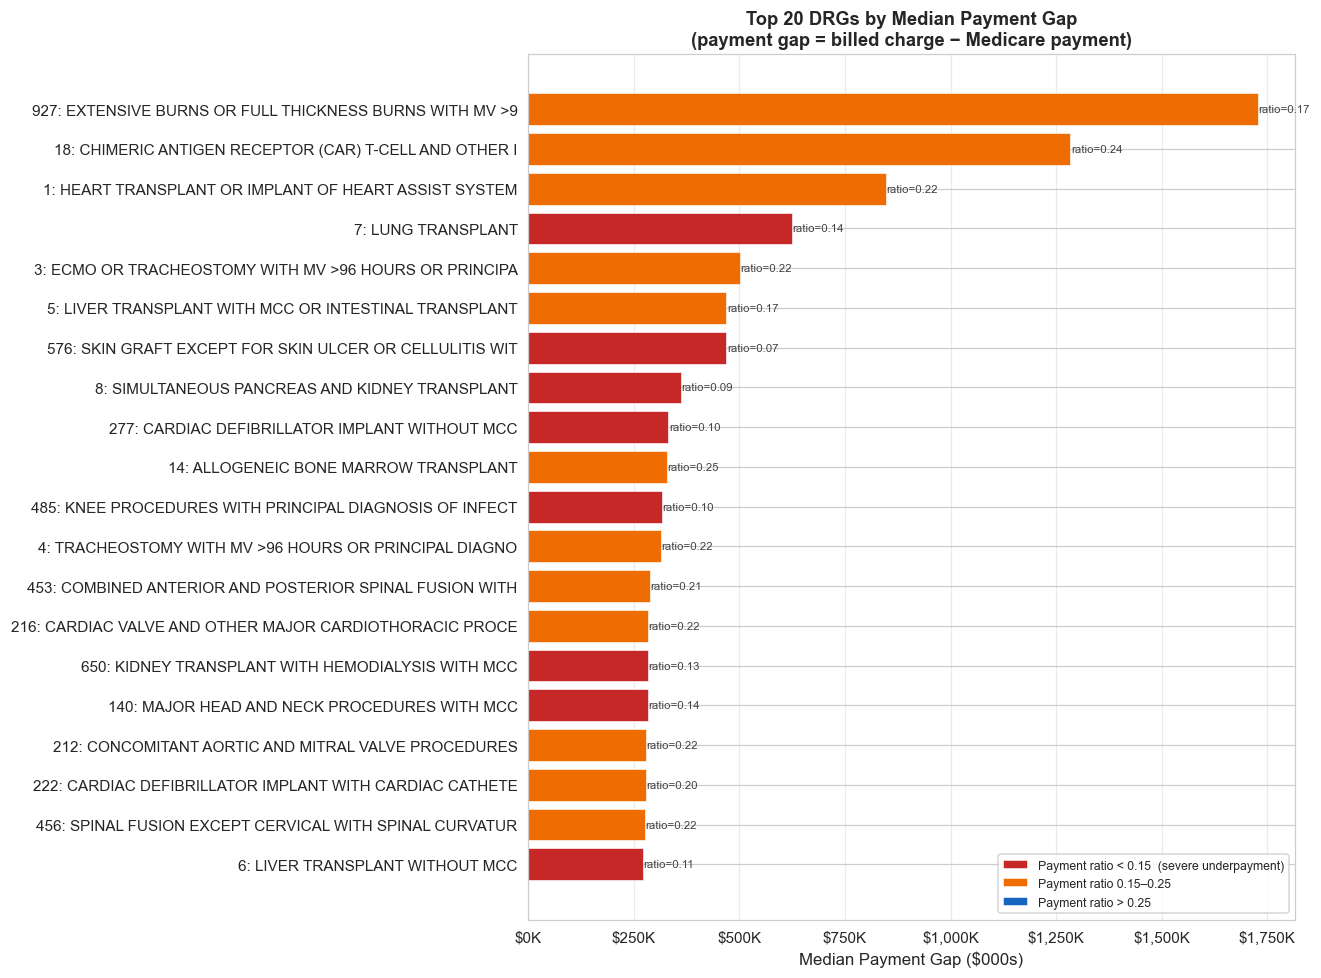

Figure 2 saved.


In [ ]:
# ── Top 20 DRGs by Median Payment Gap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

colors = [RED if r < 0.15 else ORANGE if r < 0.25 else BLUE
          for r in top20['median_ratio']]

bars = ax.barh(top20['DRG_Short'][::-1], top20['median_gap'][::-1] / 1000,
               color=colors[::-1], edgecolor='white', linewidth=0.4)

for bar, ratio in zip(bars, top20['median_ratio'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'ratio={ratio:.2f}', va='center', fontsize=7.5, color='#444')

ax.set_xlabel('Median Payment Gap ($000s)', fontsize=11)
ax.set_title('Top 20 DRGs by Median Payment Gap\n(payment gap = billed charge − Medicare payment)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED,    label='Payment ratio < 0.15  (severe underpayment)'),
    Patch(facecolor=ORANGE, label='Payment ratio 0.15–0.25'),
    Patch(facecolor=BLUE,   label='Payment ratio > 0.25'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig('rq1_fig2_top20_drg_gap.png', dpi=150, bbox_inches='tight')
plt.show()


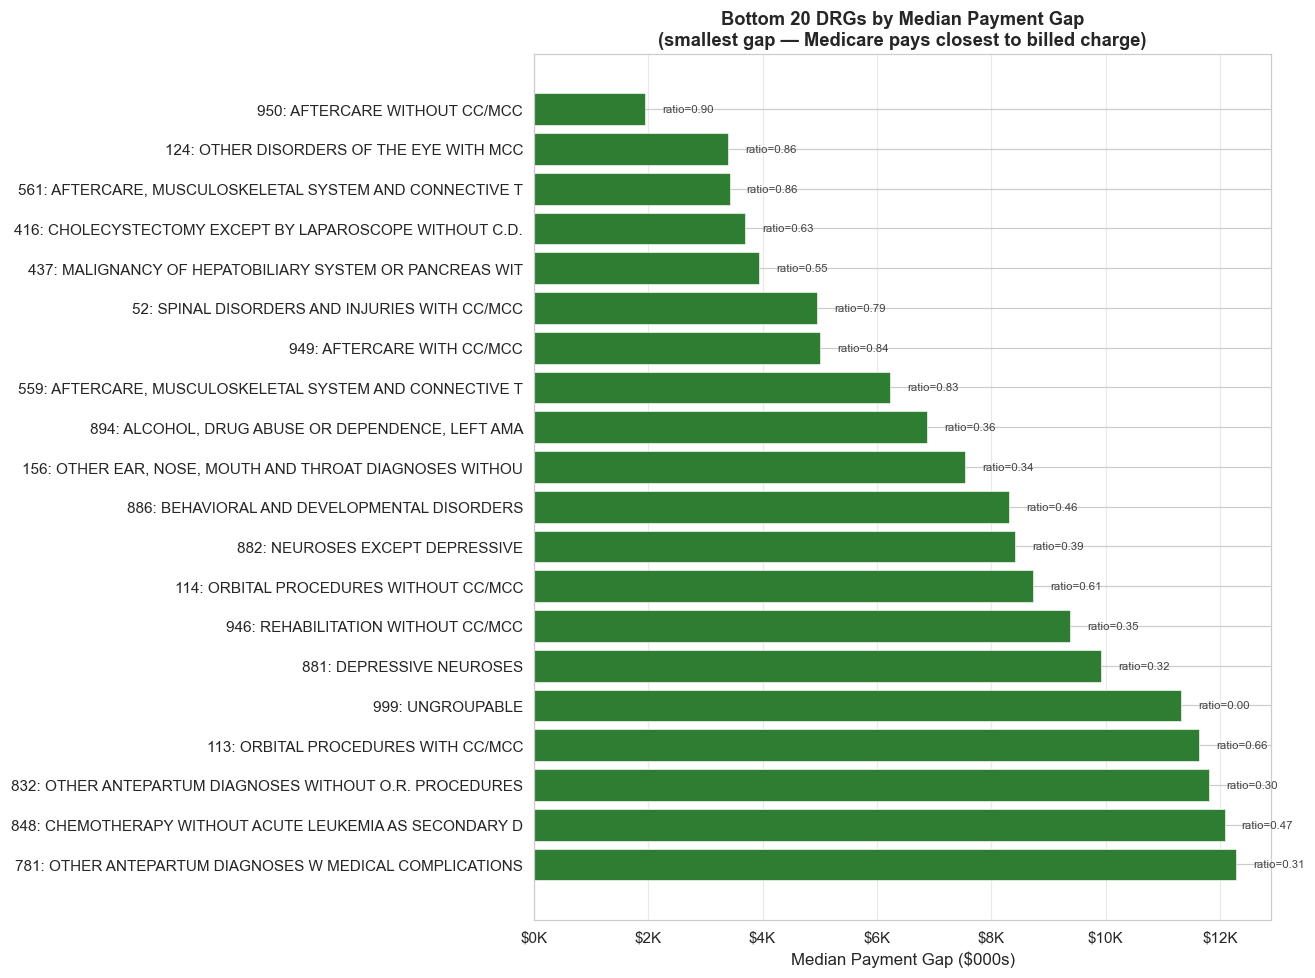

Figure 3 saved.


In [ ]:
# ── Bottom 20 DRGs by Median Payment Gap (smallest gap / best ratio) ───────
fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(bot20['DRG_Short'], bot20['median_gap'] / 1000,
        color=GREEN, edgecolor='white', linewidth=0.4)

for i, (_, row) in enumerate(bot20.iterrows()):
    ax.text(row['median_gap'] / 1000 + 0.3, i,
            f"ratio={row['median_ratio']:.2f}", va='center', fontsize=7.5, color='#444')

ax.set_xlabel('Median Payment Gap ($000s)', fontsize=11)
ax.set_title('Bottom 20 DRGs by Median Payment Gap\n(smallest gap — Medicare pays closest to billed charge)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig('rq1_fig3_bot20_drg_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Printable Top-20 DRG summary table ────────────────────────────────────
display_cols = ['DRG_Cd','DRG_Desc','median_gap','median_ratio','median_drg_weight','total_discharges']
top20_display = top20[display_cols].copy()
top20_display.columns = ['DRG','Description','Median Gap ($)','Payment Ratio','DRG Weight','Total Discharges']
top20_display['Median Gap ($)']    = top20_display['Median Gap ($)'].map('${:,.0f}'.format)
top20_display['Payment Ratio']     = top20_display['Payment Ratio'].map('{:.3f}'.format)
top20_display['DRG Weight']        = top20_display['DRG Weight'].map('{:.2f}'.format)
top20_display['Total Discharges']  = top20_display['Total Discharges'].map('{:,.0f}'.format)
top20_display['Description']       = top20_display['Description'].str[:55]

print('Top 20 DRGs by Median Payment Gap')
print('=' * 110)
print(top20_display.to_string(index=False))

Top 20 DRGs by Median Payment Gap
 DRG                                             Description Median Gap ($) Payment Ratio DRG Weight Total Discharges
 927 EXTENSIVE BURNS OR FULL THICKNESS BURNS WITH MV >96 HOU     $1,728,235         0.174      19.94               11
  18 CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTHER IMMUNO     $1,283,614         0.236      37.33            2,828
   1 HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM WITH       $846,269         0.223      27.63           10,719
   7                                         LUNG TRANSPLANT       $624,042         0.138      10.79            2,913
   3 ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DIA       $501,223         0.223      18.95           63,273
   5      LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSPLANT       $469,076         0.168      10.27            6,857
 576 SKIN GRAFT EXCEPT FOR SKIN ULCER OR CELLULITIS WITH MCC       $469,042         0.073       4.88               39
   8             SIMUL

## 4. DRG Severity (Weight) vs Payment Gap

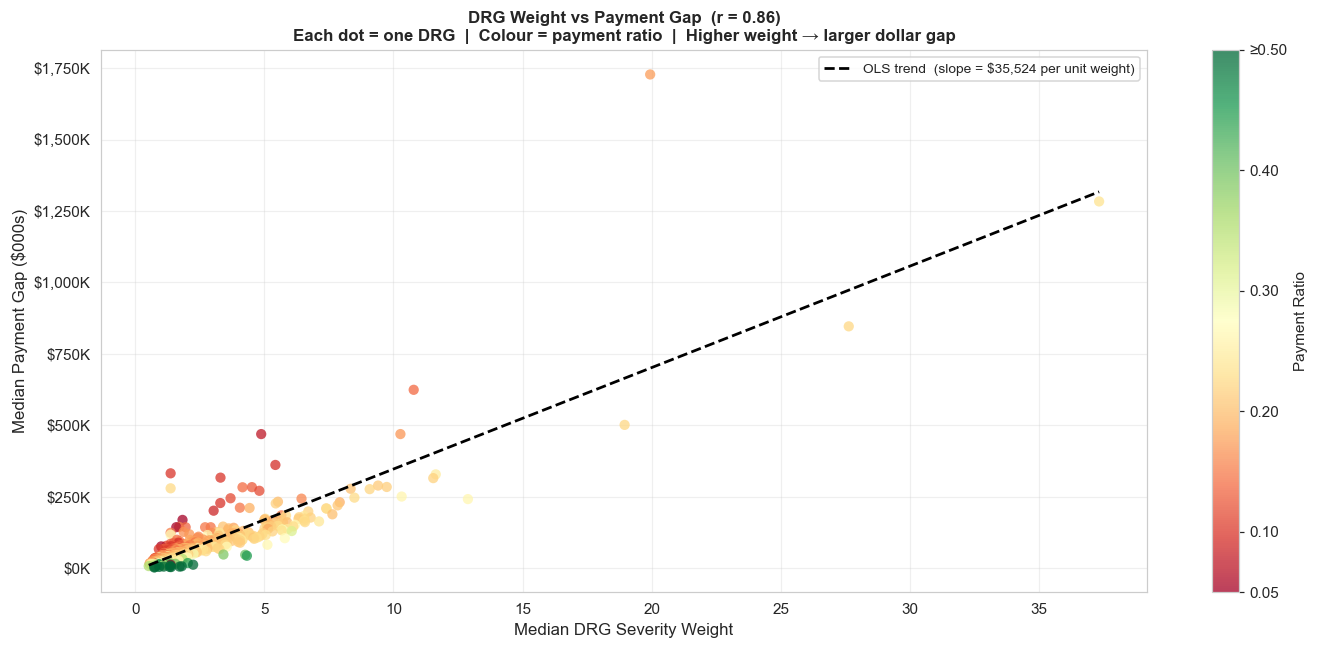

Figure 4a saved.
  OLS slope : $35,524 additional gap per 1 unit increase in DRG weight
  Intercept : $-8,679
  r         : 0.861


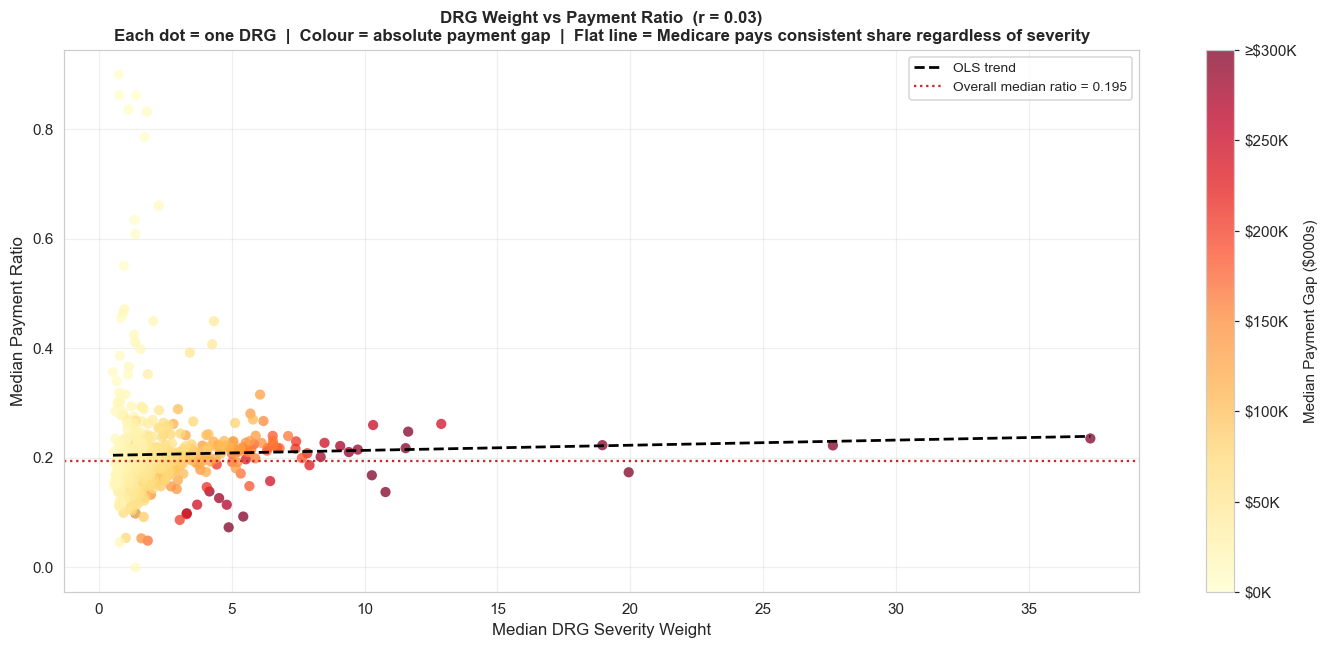

Figure 4b saved.
  r = 0.029 — essentially no relationship between weight and ratio


In [ ]:
# ── Chart 1: DRG Weight vs Payment Gap ────────────────────────────────────
scatter_df = drg_agg[drg_agg['median_gap'] > 0].copy()

fig, ax = plt.subplots(figsize=(13, 6))

sc = ax.scatter(
    scatter_df['median_drg_weight'],
    scatter_df['median_gap'] / 1000,
    c=scatter_df['median_ratio'],
    cmap='RdYlGn',
    vmin=0.05, vmax=0.50,      # cap colour scale — removes stretch from extreme outliers
    alpha=0.75, s=45, linewidths=0
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Payment Ratio', fontsize=10)
cbar.ax.set_yticks([0.05, 0.10, 0.20, 0.30, 0.40, 0.50])
cbar.ax.set_yticklabels(['0.05', '0.10', '0.20', '0.30', '0.40', '≥0.50'])

# OLS regression line
z = np.polyfit(scatter_df['median_drg_weight'], scatter_df['median_gap'] / 1000, 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['median_drg_weight'].min(),
                     scatter_df['median_drg_weight'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linewidth=1.8, linestyle='--',
        label=f'OLS trend  (slope = ${z[0]*1000:,.0f} per unit weight)')

corr = scatter_df['median_drg_weight'].corr(scatter_df['median_gap'])
ax.set_xlabel('Median DRG Severity Weight', fontsize=11)
ax.set_ylabel('Median Payment Gap ($000s)', fontsize=11)
ax.set_title(
    f'DRG Weight vs Payment Gap  (r = {corr:.2f})\n'
    f'Each dot = one DRG  |  Colour = payment ratio  |  '
    f'Higher weight → larger dollar gap',
    fontsize=11
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('rq1_fig4a_weight_vs_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 4a saved.')
print(f'  OLS slope : ${z[0]*1000:,.0f} additional gap per 1 unit increase in DRG weight')
print(f'  Intercept : ${z[1]*1000:,.0f}')
print(f'  r         : {corr:.3f}')

# ── Chart 2: DRG Weight vs Payment Ratio ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

sc2 = ax.scatter(
    scatter_df['median_drg_weight'],
    scatter_df['median_ratio'],
    c=scatter_df['median_gap'] / 1000,
    cmap='YlOrRd',
    vmin=0, vmax=300,          # cap at $300K so low-gap DRGs show colour contrast
    alpha=0.75, s=45, linewidths=0
)
cbar2 = plt.colorbar(sc2, ax=ax)
cbar2.set_label('Median Payment Gap ($000s)', fontsize=10)
cbar2.ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
cbar2.ax.set_yticklabels(['$0K', '$50K', '$100K', '$150K', '$200K', '$250K', '≥$300K'])

z2 = np.polyfit(scatter_df['median_drg_weight'], scatter_df['median_ratio'], 1)
p2 = np.poly1d(z2)
ax.plot(x_line, p2(x_line), color='black', linewidth=1.8, linestyle='--',
        label='OLS trend')
ax.axhline(scatter_df['median_ratio'].median(), color=RED, linestyle=':',
           linewidth=1.5, label=f'Overall median ratio = {scatter_df["median_ratio"].median():.3f}')

corr2 = scatter_df['median_drg_weight'].corr(scatter_df['median_ratio'])
ax.set_xlabel('Median DRG Severity Weight', fontsize=11)
ax.set_ylabel('Median Payment Ratio', fontsize=11)
ax.set_title(
    f'DRG Weight vs Payment Ratio  (r = {corr2:.2f})\n'
    f'Each dot = one DRG  |  Colour = absolute payment gap  |  '
    f'Flat line = Medicare pays consistent share regardless of severity',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('rq1_fig4b_weight_vs_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 4b saved.')
print(f'  r = {corr2:.3f} — {"essentially no relationship" if abs(corr2) < 0.1 else "some relationship"} between weight and ratio')



 ## Chart 1 — DRG Weight vs Payment Gap (r = 0.86)
  x-axis (DRG weight) & the y-axis is payment ratio instead of absolute gap. The colour  where darker orange = larger absolute payment gap.

- Strong positive relationship — heavier DRGs reliably produce larger dollar gaps
- Every 1 unit increase in DRG weight adds ~$35,524 to the median payment gap
- The dense cluster at weight 1–5 (most common DRGs) all have gaps below $250K
- A few high-weight outliers (weight 20+) have gaps of $500K–$1.75M
- Red dots (low payment ratio) appear across all weight levels — even low-severity DRGs can have poor reimbursement rates
- Green dots (better ratio ≥0.50) are almost entirely in the low-weight, low-gap cluster — small procedures where Medicare covers a higher share

## Chart 2 — DRG Weight vs Payment Ratio (r = 0.03)
x-axis — DRG severity weight. Higher = Medicare considers this diagnosis more complex and pays more
y-axis — median payment gap in $000s for that DRG across all hospitals and years
Colour — payment ratio using a Red-Yellow-Green colormap. Red dots = low ratio (Medicare pays a small share of billed charge).
 Green dots = high ratio (Medicare pays a larger share)

- Nearly flat OLS line confirms weight has almost zero relationship with payment ratio
- Regardless of whether DRG weight is 1 or 37, Medicare pays roughly the same ~20% share of the billed charge
- The wide vertical spread at low weights (0.0 to 0.9 ratio) means low-severity DRGs are actually the most inconsistent — some get excellent reimbursement, others get very little
- High-weight DRGs (15+) converge tightly around the 0.20 median — less variability, more predictable reimbursement rate
- Dark red dots (gap >$300K) cluster around the median ratio line — large dollar gaps don't mean a worse proportional rate, just a higher billed charge

## Combined Inference

The two charts together tell one story: **severity drives the size of the gap in dollars but not in proportion.** 
Medicare increases payments when a case is more complex, so hospitals get larger payments for serious cases. But hospitals also increase their billed charges at the same rate. Because both rise together, Medicare ends up paying about 20% of the total charges regardless of how sick the patient is.

### Graph 2 - DRG Weight vs Payment Ratio


## 5. Payment Gap Trend Over Time (2017–2023)

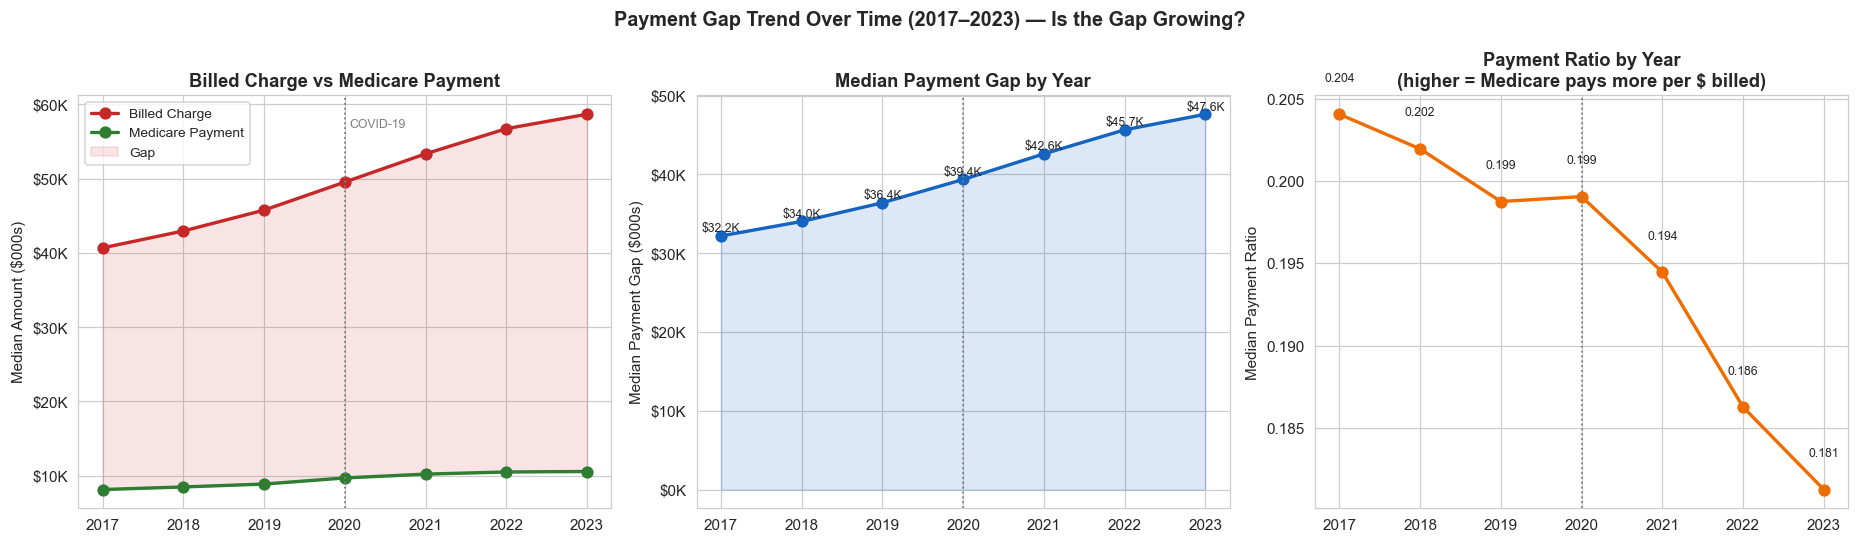

Figure 5 saved.
 Data_Year  median_charge  median_payment   median_gap  median_ratio
      2017   40670.096405     8120.066964 32193.882214      0.204051
      2018   42947.785714     8468.530973 34028.714286      0.201946
      2019   45756.466667     8858.402299 36403.400000      0.198752
      2020   49531.076923     9682.500000 39362.538462      0.199050
      2021   53338.333330    10196.000000 42608.277770      0.194467
      2022   56725.299831    10486.851290 45657.657870      0.186278
      2023   58668.571430    10548.181820 47638.090910      0.181266


In [ ]:
# ── Year-level aggregation ─────────────────────────────────────────────────
yr_agg = (
    df.groupby('Data_Year')
    .agg(
        median_gap     = ('Payment_Gap',               'median'),
        median_charge  = ('Avg_Submtd_Cvrd_Chrg',      'median'),
        median_payment = ('Avg_Mdcr_Pymt_Amt',         'median'),
        median_ratio   = ('Payment_Ratio',             'median'),
        pct_gap_growth = ('Payment_Gap',               lambda x: x.median())
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Payment Gap Trend Over Time (2017–2023) — Is the Gap Growing?', fontsize=13, fontweight='bold')

years = yr_agg['Data_Year']

# Panel 1 — Median billed charge vs Medicare payment
axes[0].plot(years, yr_agg['median_charge']/1000, 'o-', color=RED,  linewidth=2.2, markersize=7, label='Billed Charge')
axes[0].plot(years, yr_agg['median_payment']/1000,'o-', color=GREEN, linewidth=2.2, markersize=7, label='Medicare Payment')
axes[0].fill_between(years, yr_agg['median_payment']/1000, yr_agg['median_charge']/1000, alpha=0.12, color=RED, label='Gap')
axes[0].set_ylabel('Median Amount ($000s)', fontsize=10)
axes[0].set_title('Billed Charge vs Medicare Payment')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
axes[0].legend(fontsize=9)
axes[0].set_xticks(years)
axes[0].axvline(2020, color='grey', linestyle=':', linewidth=1.2)
axes[0].text(2020.05, yr_agg['median_charge'].max()/1000 * 0.97, 'COVID-19', fontsize=8, color='grey')

# Panel 2 — Median payment gap
axes[1].plot(years, yr_agg['median_gap']/1000, 'o-', color=BLUE, linewidth=2.2, markersize=7)
axes[1].fill_between(years, 0, yr_agg['median_gap']/1000, alpha=0.15, color=BLUE)
for x, y in zip(years, yr_agg['median_gap']):
    axes[1].text(x, y/1000 + 0.5, f'${y/1000:.1f}K', ha='center', fontsize=8)
axes[1].set_ylabel('Median Payment Gap ($000s)', fontsize=10)
axes[1].set_title('Median Payment Gap by Year')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
axes[1].set_xticks(years)
axes[1].axvline(2020, color='grey', linestyle=':', linewidth=1.2)

# Panel 3 — Payment ratio
axes[2].plot(years, yr_agg['median_ratio'], 'o-', color=ORANGE, linewidth=2.2, markersize=7)
for x, y in zip(years, yr_agg['median_ratio']):
    axes[2].text(x, y + 0.002, f'{y:.3f}', ha='center', fontsize=8)
axes[2].set_ylabel('Median Payment Ratio', fontsize=10)
axes[2].set_title('Payment Ratio by Year\n(higher = Medicare pays more per $ billed)')
axes[2].set_xticks(years)
axes[2].axvline(2020, color='grey', linestyle=':', linewidth=1.2)

plt.tight_layout()
#plt.savefig('rq1_fig5_trend_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(yr_agg[['Data_Year','median_charge','median_payment','median_gap','median_ratio']].to_string(index=False))

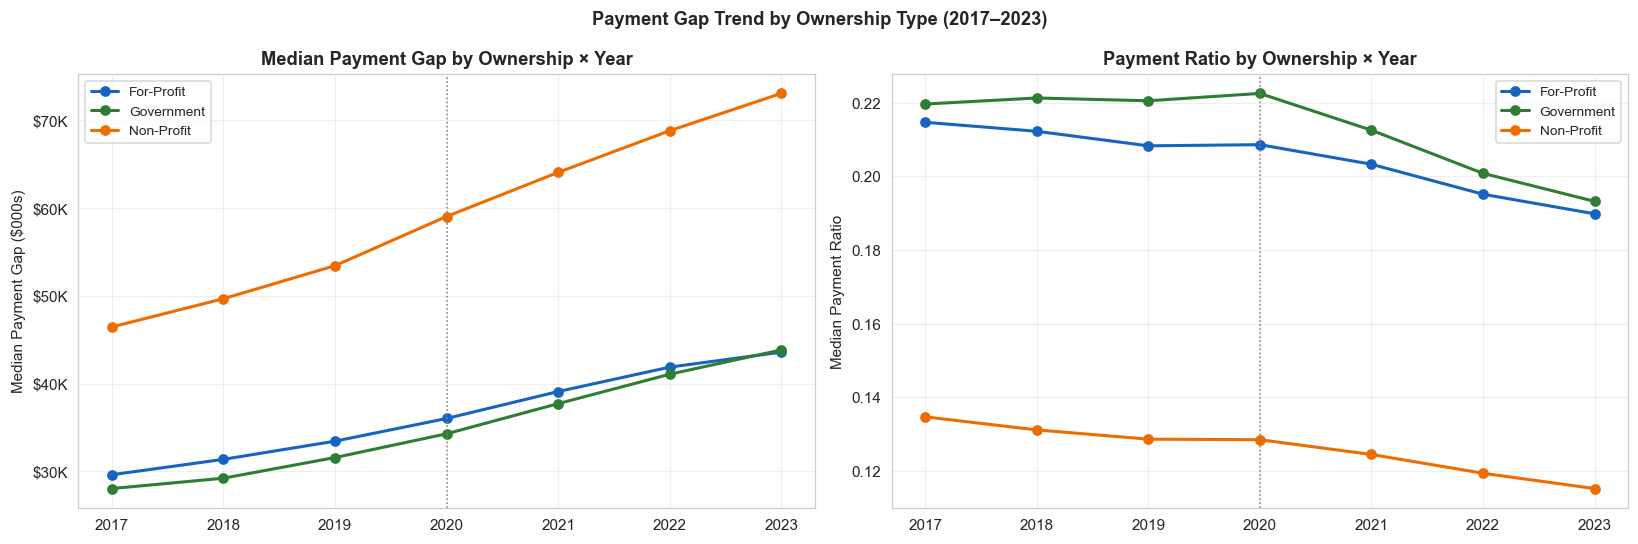

Figure 6 saved.


In [ ]:
# ── Trend by Ownership Type ────────────────────────────────────────────────
yr_own = (
    df_own.groupby(['Data_Year','Ownership_Type'])
    .agg(median_gap   = ('Payment_Gap',   'median'),
         median_ratio = ('Payment_Ratio', 'median'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Payment Gap Trend by Ownership Type (2017–2023)', fontsize=12, fontweight='bold')

for own_type, grp in yr_own.groupby('Ownership_Type'):
    c = OWN_PALETTE[own_type]
    axes[0].plot(grp['Data_Year'], grp['median_gap']/1000, 'o-', color=c, linewidth=2, markersize=6, label=own_type)
    axes[1].plot(grp['Data_Year'], grp['median_ratio'],    'o-', color=c, linewidth=2, markersize=6, label=own_type)

for ax, title, ylabel, fmt in zip(
    axes,
    ['Median Payment Gap by Ownership × Year', 'Payment Ratio by Ownership × Year'],
    ['Median Payment Gap ($000s)', 'Median Payment Ratio'],
    [lambda x, _: f'${x:,.0f}K', None]
):
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xticks(yr_own['Data_Year'].unique())
    ax.axvline(2020, color='grey', linestyle=':', linewidth=1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if fmt: ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))

plt.tight_layout()
#plt.savefig('rq1_fig6_trend_by_ownership.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')


## 📊 Graph Insights: Payment Gap Trend by Ownership Type (2017–2023)

**What the chart shows:**
- Two line charts tracking how the median payment gap (in $000s) and the median payment ratio
  changed across three hospital ownership types — For-Profit, Government, and Non-Profit —
  from 2017 to 2023. The dotted vertical line marks 2020 (COVID-19 onset).

**Key findings — Payment Gap (left panel):**
- Non-Profit hospitals consistently carry the largest payment gap, rising steeply from ~$46K
  in 2017 to over $72K in 2023 — a 57% increase over six years.
- For-Profit and Government hospitals start much lower (~$29–30K in 2017) and grow more
  gradually, converging near $44K by 2023.
- The gap between Non-Profit and the other two ownership types widens noticeably after 2020,
  suggesting COVID-era billing or reimbursement shifts disproportionately affected Non-Profits.

**Key findings — Payment Ratio (right panel):**
- All three ownership types show a declining payment ratio after 2020, meaning Medicare is
  paying a smaller fraction of submitted charges over time.
- Government hospitals held the highest ratio (~0.22) through 2020 but dropped sharply
  after — falling to ~0.19 by 2023, nearly matching For-Profit levels.
- Non-Profit hospitals have the lowest payment ratio throughout (0.13–0.11), meaning Medicare
  consistently reimburses a smaller share of what Non-Profits charge compared to other types.
- The post-2020 convergence of For-Profit and Government ratios suggests ownership-type
  differences in reimbursement efficiency are shrinking.

**What this means for the Medicare analysis:**
- These trends directly support RQ1 (Payment Variation) — ownership type is a meaningful
  driver of both how large the payment gap is and how efficiently Medicare reimburses.
  The post-2020 divergence in Non-Profit gap growth is worth investigating further as a
  potential feature or interaction term in the prediction model (RQ2).


## 6. Payment Gap by Ownership Type

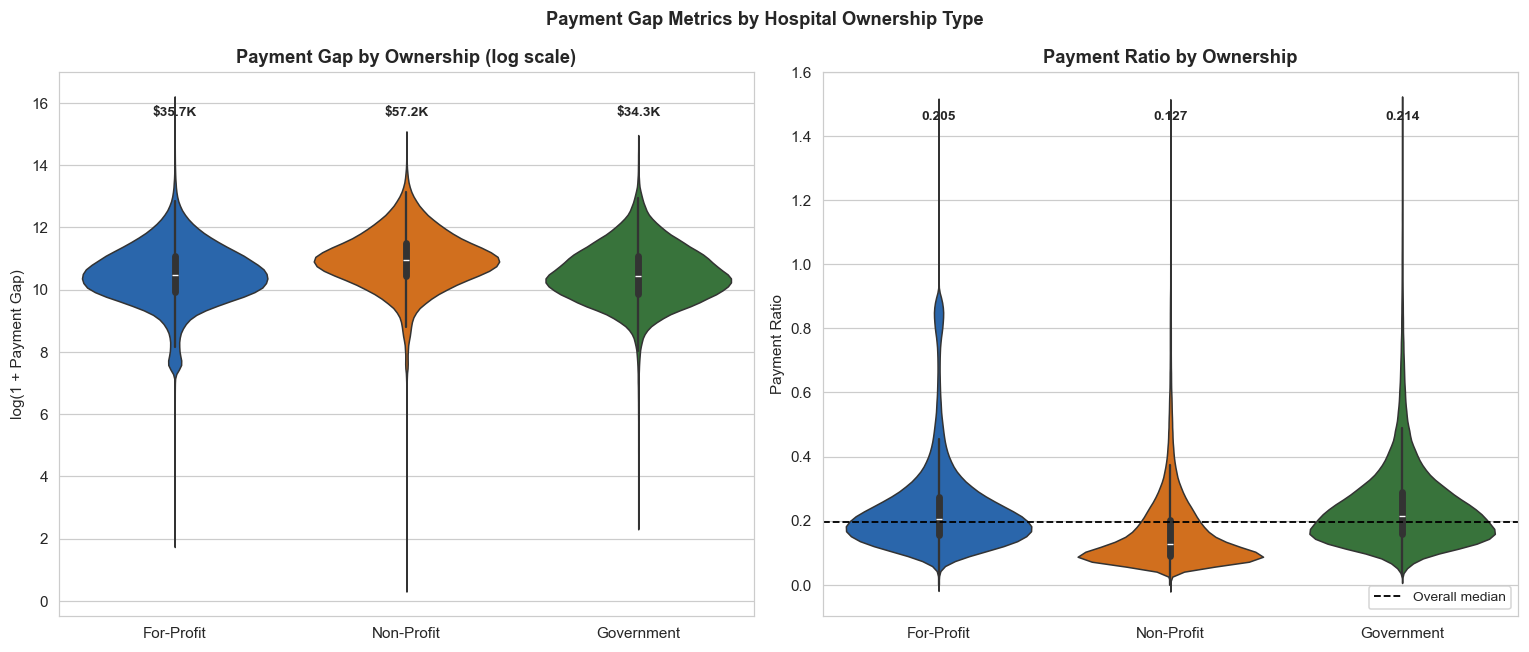

Figure 7 saved.


In [ ]:
# ── Box + violin: Payment Gap and Ratio by Ownership ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Payment Gap Metrics by Hospital Ownership Type', fontsize=12, fontweight='bold')

own_order = ['For-Profit','Non-Profit','Government']

# Panel 1 — Payment Gap (log scale)
plot_df = df_own[df_own['Payment_Gap'] > 0].copy()
plot_df['log_gap'] = np.log1p(plot_df['Payment_Gap'])
sns.violinplot(data=plot_df, x='Ownership_Type', y='log_gap', order=own_order,
               palette=OWN_PALETTE, inner='box', ax=axes[0], linewidth=1)
axes[0].set_xlabel('')
axes[0].set_ylabel('log(1 + Payment Gap)', fontsize=10)
axes[0].set_title('Payment Gap by Ownership (log scale)')
medians_gap = plot_df.groupby('Ownership_Type')['Payment_Gap'].median()
for i, own in enumerate(own_order):
    axes[0].text(i, plot_df['log_gap'].max() * 0.97,
                 f'${medians_gap.get(own,0)/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')

# Panel 2 — Payment Ratio
sns.violinplot(data=df_own[df_own['Payment_Ratio'] <= 1.5],
               x='Ownership_Type', y='Payment_Ratio', order=own_order,
               palette=OWN_PALETTE, inner='box', ax=axes[1], linewidth=1)
axes[1].axhline(df_own['Payment_Ratio'].median(), color='black', linestyle='--', linewidth=1.2, label='Overall median')
axes[1].set_xlabel('')
axes[1].set_ylabel('Payment Ratio', fontsize=10)
axes[1].set_title('Payment Ratio by Ownership')
medians_ratio = df_own.groupby('Ownership_Type')['Payment_Ratio'].median()
for i, own in enumerate(own_order):
    axes[1].text(i, 1.45, f'{medians_ratio.get(own,0):.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
#plt.savefig('rq1_fig7_ownership_gap.png', dpi=150, bbox_inches='tight')
plt.show()


## 📊 Graph Insights: Payment Gap Metrics by Hospital Ownership Type (Violin Plots)

**What the chart shows:**
- Two violin plots comparing the distribution of payment gap (log scale) and payment ratio
  across For-Profit, Non-Profit, and Government hospitals. The dashed line on the right
  panel marks the overall median payment ratio (0.20).

**Key findings — Payment Gap Distribution (left panel):**
- Non-Profit hospitals have the highest median payment gap at $57.2K, compared to $35.7K
  for For-Profit and $34.3K for Government — consistent with the trend charts above.
- Non-Profit's violin is wider in the upper range, indicating more providers with very
  large payment gaps, not just a higher average.
- For-Profit and Government distributions look similar in shape — relatively compact and
  symmetric — while Non-Profit is more top-heavy.

**Key findings — Payment Ratio Distribution (right panel):**
- Government (0.214) and For-Profit (0.205) hospitals sit right at or above the overall
  median ratio, while Non-Profit (0.127) falls well below it.
- Non-Profit's payment ratio violin is heavily concentrated below 0.20, with a long upper
  tail — meaning most Non-Profits receive a low ratio, but a small number receive
  unusually high ratios.
- For-Profit shows the broadest spread in payment ratio, with the widest violin body,
  suggesting high variability in how efficiently individual For-Profit hospitals are reimbursed.

**What this means for the Medicare analysis:**
- The distribution shapes confirm that ownership type is not just a mean-level difference —
  it reflects genuinely different billing and reimbursement patterns (RQ1). Non-Profits
  charge more but recover less proportionally. The long tails visible in all three groups
  also signal the presence of outlier providers that the Isolation Forest anomaly detection
  model (RQ4) should investigate.


## 7. Payment Gap by Geography (RUCA)

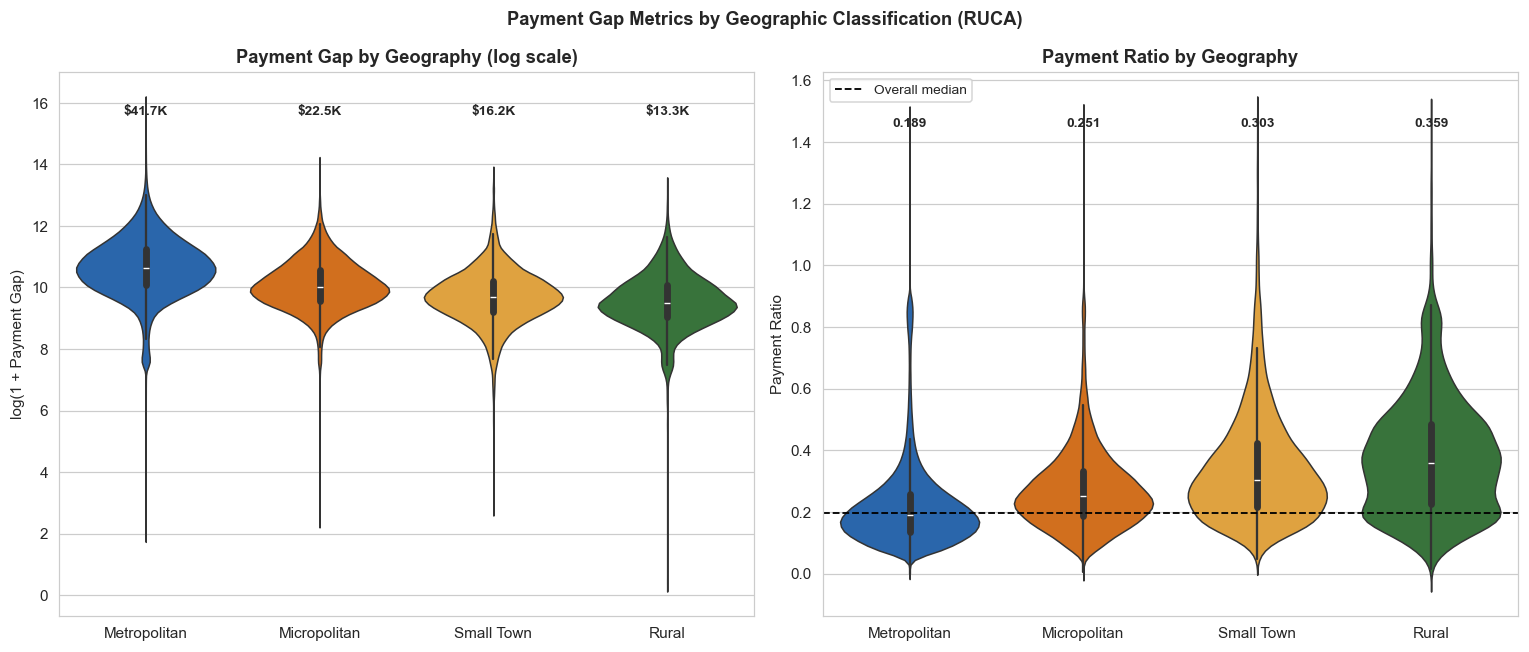

Figure 8 saved.


In [ ]:
# ── Box + violin: Payment Gap and Ratio by RUCA Group ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Payment Gap Metrics by Geographic Classification (RUCA)', fontsize=12, fontweight='bold')

geo_pos = df_geo[df_geo['Payment_Gap'] > 0].copy()
geo_pos['log_gap'] = np.log1p(geo_pos['Payment_Gap'])

# Panel 1 — Payment Gap
sns.violinplot(data=geo_pos, x='RUCA_Group', y='log_gap', order=RUCA_ORDER,
               palette=RUCA_PALETTE, inner='box', ax=axes[0], linewidth=1)
axes[0].set_xlabel('')
axes[0].set_ylabel('log(1 + Payment Gap)')
axes[0].set_title('Payment Gap by Geography (log scale)')
medians_g = geo_pos.groupby('RUCA_Group')['Payment_Gap'].median()
for i, g in enumerate(RUCA_ORDER):
    axes[0].text(i, geo_pos['log_gap'].max()*0.97,
                 f'${medians_g.get(g,0)/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')

# Panel 2 — Payment Ratio
sns.violinplot(data=df_geo[df_geo['Payment_Ratio'] <= 1.5],
               x='RUCA_Group', y='Payment_Ratio', order=RUCA_ORDER,
               palette=RUCA_PALETTE, inner='box', ax=axes[1], linewidth=1)
axes[1].axhline(df_geo['Payment_Ratio'].median(), color='black', linestyle='--', linewidth=1.2, label='Overall median')
axes[1].set_xlabel('')
axes[1].set_ylabel('Payment Ratio')
axes[1].set_title('Payment Ratio by Geography')
medians_rr = df_geo.groupby('RUCA_Group')['Payment_Ratio'].median()
for i, g in enumerate(RUCA_ORDER):
    axes[1].text(i, 1.45, f'{medians_rr.get(g,0):.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
#plt.savefig('rq1_fig8_ruca_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Graph Insights: Payment Gap Metrics by Geographic Classification (RUCA)

**What the chart shows:**
- Two side-by-side violin plots comparing Medicare payment gaps (log scale) and payment ratios
  across four geographic categories: Metropolitan, Micropolitan, Small Town, and Rural.

**Key findings — Payment Gap (left plot):**
- Metropolitan hospitals have the largest median payment gap at $41.7K — more than 3x that
  of Rural hospitals ($13.3K), indicating urban providers bill far more unreimbursed costs.
- The gap decreases steadily with rurality: Metropolitan ($41.7K) → Micropolitan ($22.5K) →
  Small Town ($16.2K) → Rural ($13.3K), showing a clear urban-to-rural gradient.
- Metropolitan violins are wider and taller, reflecting greater volume and variability in billing
  at large urban hospitals; rural violins are narrower and more compressed.

**Key findings — Payment Ratio (right plot):**
- The pattern reverses for payment ratio: Rural providers have the highest median ratio (0.359),
  meaning Medicare covers ~36% of billed charges, while Metropolitan providers have the lowest (0.189).
- All four groups fall near the overall median dashed line (~0.20), but Rural and Small Town
  distributions show longer upper tails — some rural providers receive ratios above 0.8.
- Metropolitan providers cluster tightly below 0.20, suggesting that large urban hospitals bill
  far more than Medicare reimburses relative to their total charges.

**What this means for the Medicare analysis:**
- These findings directly support RQ2 (Geographic Efficiency): urban hospitals generate larger
  absolute payment gaps but receive a lower share of billed charges, while rural hospitals bill
  less overall but recover a proportionally higher fraction — pointing to structurally different
  billing behaviors by geography that should be factored into the predictive model.

## 8. State-Level Payment Gap

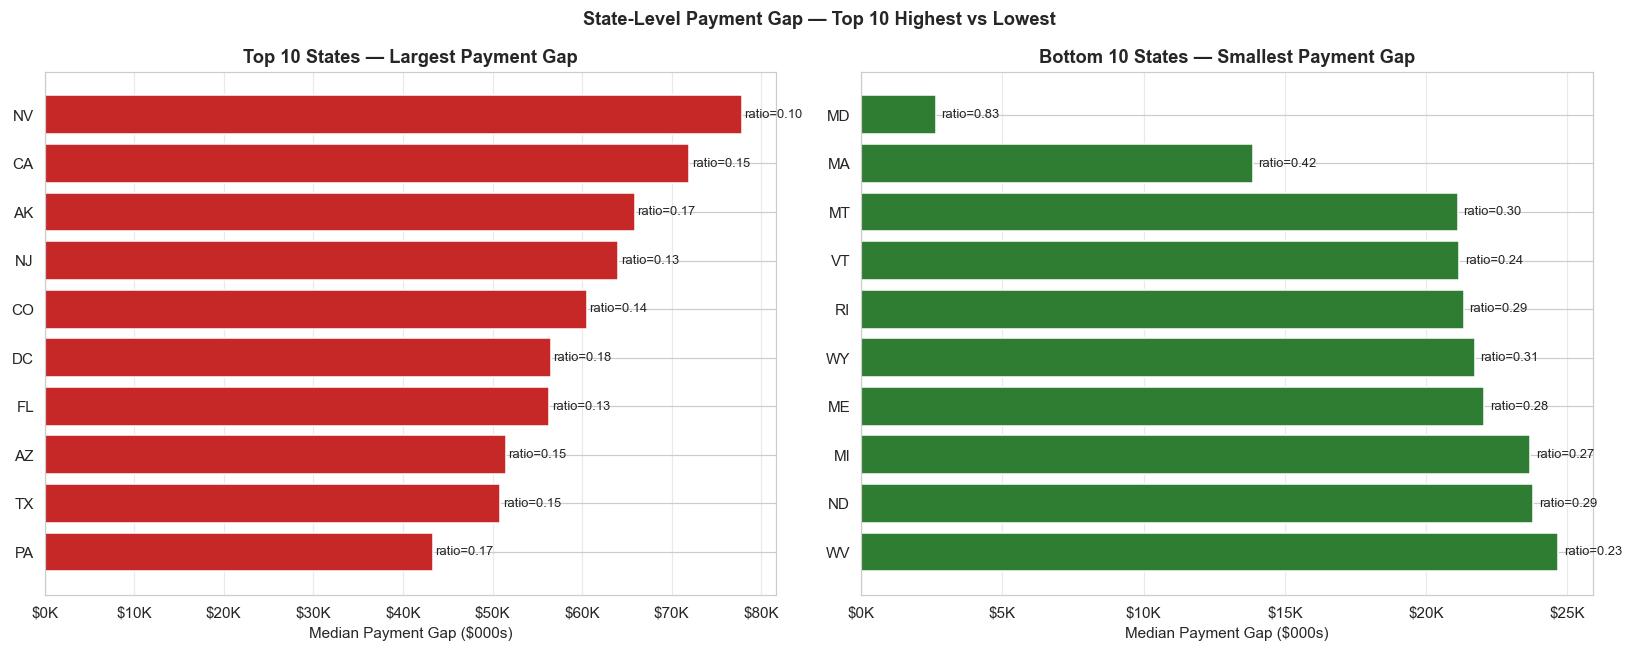

Figure 9 saved.

Top 10 states by median payment gap:
State   median_gap  median_ratio  n_records
   NV 77808.818755      0.103281      10426
   CA 71958.578125      0.147109      96181
   AK 65889.888889      0.168359       1971
   NJ 64027.876580      0.134348      37126
   CO 60531.616086      0.138274      13232
   DC 56497.966932      0.178111       4238
   FL 56317.352941      0.131363      91571
   AZ 51497.529420      0.153568      22207
   TX 50869.008772      0.151702      81306
   PA 43323.416669      0.166511      55346


In [ ]:
# ── State-level aggregation ────────────────────────────────────────────────
state_agg = (
    df.groupby('Rndrng_Prvdr_State_Abrvtn')
    .agg(
        median_gap    = ('Payment_Gap',   'median'),
        median_ratio  = ('Payment_Ratio', 'median'),
        n_records     = ('DRG_Cd',        'count')
    )
    .reset_index()
    .rename(columns={'Rndrng_Prvdr_State_Abrvtn': 'State'})
    .sort_values('median_gap', ascending=False)
)

top10_states = state_agg.head(10)
bot10_states = state_agg.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('State-Level Payment Gap — Top 10 Highest vs Lowest', fontsize=12, fontweight='bold')

# Top 10 highest gap states
axes[0].barh(top10_states['State'][::-1], top10_states['median_gap'][::-1]/1000,
             color=RED, edgecolor='white')
for i, (_, row) in enumerate(top10_states[::-1].iterrows()):
    axes[0].text(row['median_gap']/1000 + 0.3, i,
                 f"ratio={row['median_ratio']:.2f}", va='center', fontsize=8.5)
axes[0].set_xlabel('Median Payment Gap ($000s)')
axes[0].set_title('Top 10 States — Largest Payment Gap')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
axes[0].grid(axis='x', alpha=0.4)

# Bottom 10 lowest gap states
axes[1].barh(bot10_states['State'], bot10_states['median_gap']/1000,
             color=GREEN, edgecolor='white')
for i, (_, row) in enumerate(bot10_states.iterrows()):
    axes[1].text(row['median_gap']/1000 + 0.2, i,
                 f"ratio={row['median_ratio']:.2f}", va='center', fontsize=8.5)
axes[1].set_xlabel('Median Payment Gap ($000s)')
axes[1].set_title('Bottom 10 States — Smallest Payment Gap')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
#plt.savefig('rq1_fig9_state_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 states by median payment gap:')
print(top10_states[['State','median_gap','median_ratio','n_records']].to_string(index=False))

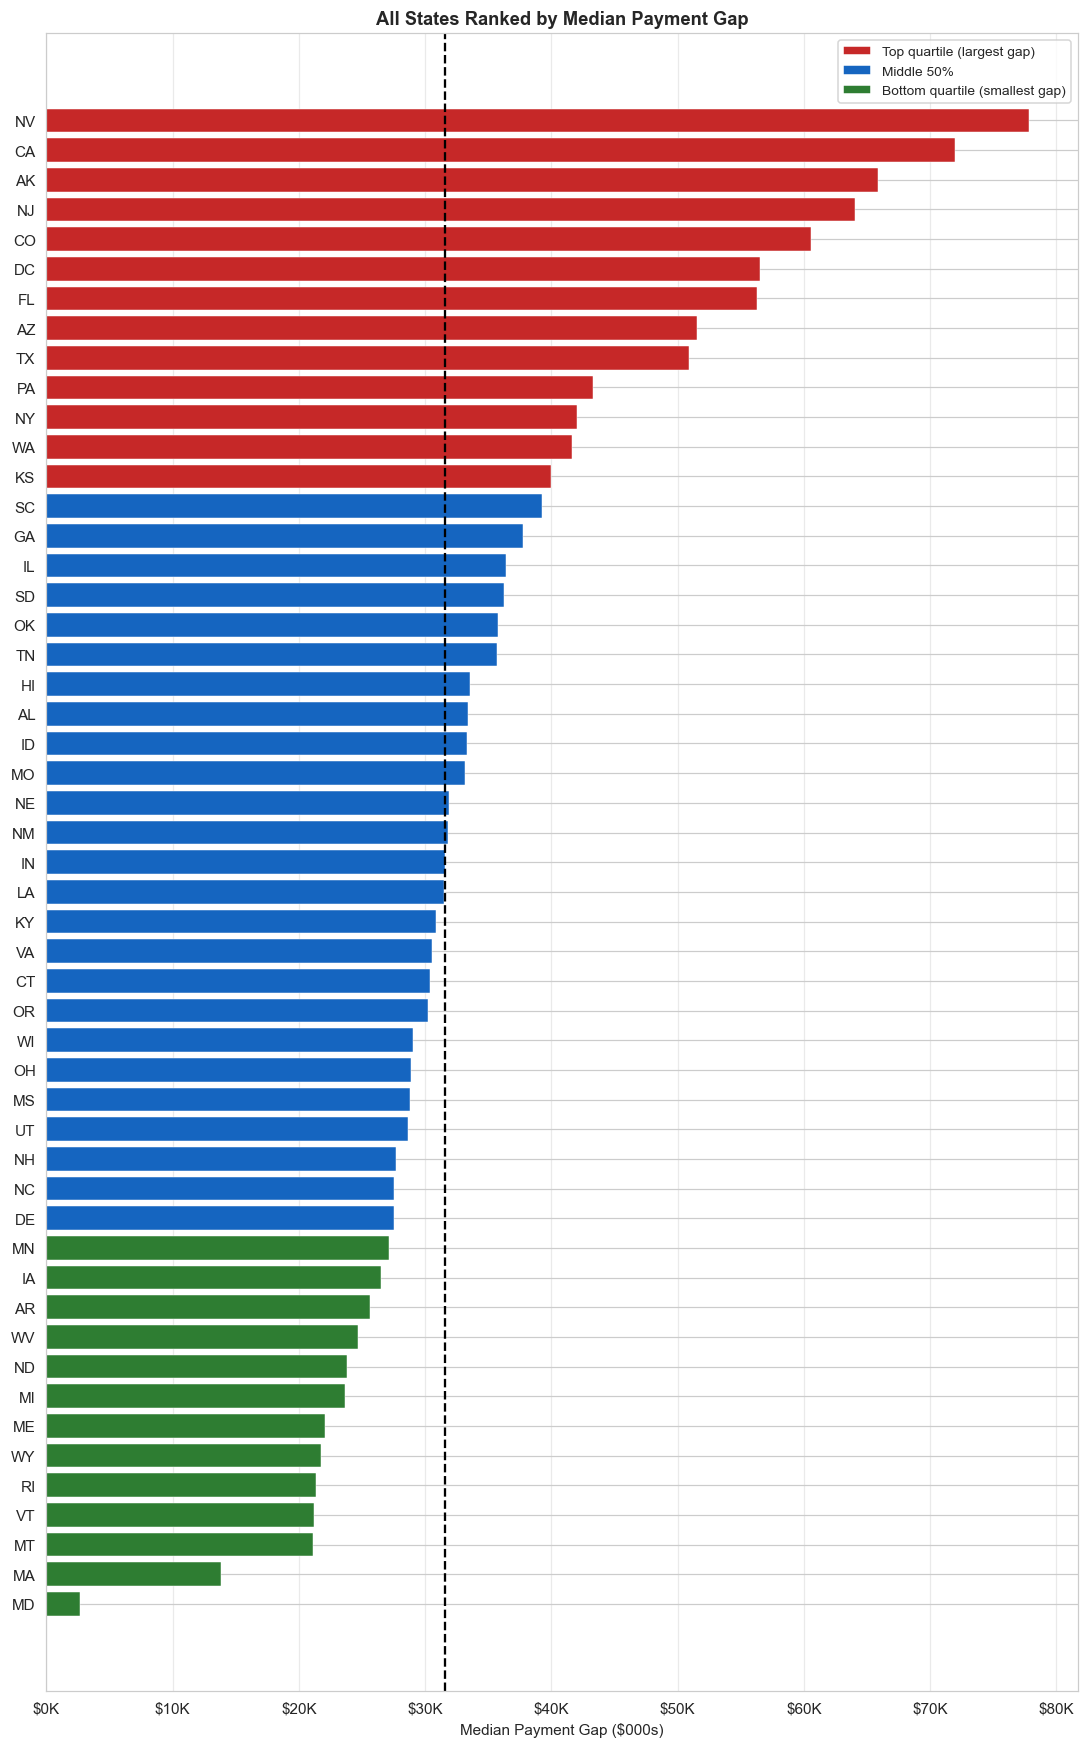

Figure 10 saved.


In [ ]:
# ── Full state ranking chart (all states) ─────────────────────────────────
state_sorted = state_agg.sort_values('median_gap')

fig, ax = plt.subplots(figsize=(10, 16))
bar_colors = [RED if g > state_agg['median_gap'].quantile(0.75)
              else GREEN if g < state_agg['median_gap'].quantile(0.25)
              else BLUE
              for g in state_sorted['median_gap']]

ax.barh(state_sorted['State'], state_sorted['median_gap']/1000,
        color=bar_colors, edgecolor='white', linewidth=0.3)
ax.axvline(state_agg['median_gap'].median()/1000, color='black',
           linestyle='--', linewidth=1.5, label='National median')
ax.set_xlabel('Median Payment Gap ($000s)')
ax.set_title('All States Ranked by Median Payment Gap', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_el = [
    Patch(facecolor=RED,   label='Top quartile (largest gap)'),
    Patch(facecolor=BLUE,  label='Middle 50%'),
    Patch(facecolor=GREEN, label='Bottom quartile (smallest gap)'),
]
ax.legend(handles=legend_el, fontsize=9)

plt.tight_layout()
#plt.savefig('rq1_fig10_all_states_ranked.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Ownership × Geography Interaction

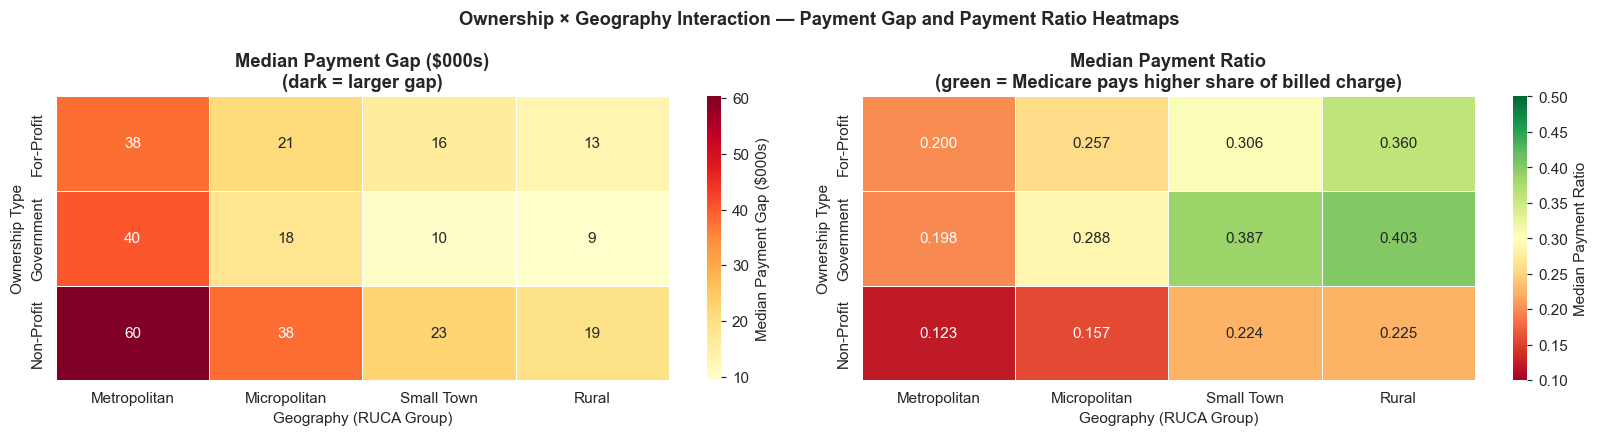


Payment Ratio — Ownership × Geography:
RUCA_Group      Metropolitan  Micropolitan  Small Town     Rural
Ownership_Type                                                  
For-Profit          0.199702      0.256952    0.305510  0.360374
Government          0.197701      0.288307    0.387373  0.402802
Non-Profit          0.122776      0.156821    0.223567  0.224756


In [49]:
# ── Interaction: Ownership × RUCA for Payment Gap and Ratio ───────────────
interact_df = (
    df[(df['Ownership_Type'].isin(['For-Profit','Non-Profit','Government'])) &
       (df['RUCA_Group'] != 'Unknown')]
    .groupby(['Ownership_Type','RUCA_Group'])
    .agg(median_ratio = ('Payment_Ratio', 'median'),
         median_gap   = ('Payment_Gap',   'median'),
         n            = ('DRG_Cd',        'count'))
    .reset_index()
)

# Pivot for heatmaps
pivot_ratio = interact_df.pivot(index='Ownership_Type', columns='RUCA_Group', values='median_ratio')
pivot_ratio = pivot_ratio[RUCA_ORDER]
pivot_gap   = interact_df.pivot(index='Ownership_Type', columns='RUCA_Group', values='median_gap')
pivot_gap   = pivot_gap[RUCA_ORDER] / 1000

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Ownership × Geography Interaction — Payment Gap and Payment Ratio Heatmaps', fontsize=12, fontweight='bold')

# Left: Payment Gap — dark = larger gap
sns.heatmap(pivot_gap, ax=axes[0], annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Median Payment Gap ($000s)'})
axes[0].set_title('Median Payment Gap ($000s)\n(dark = larger gap)')
axes[0].set_xlabel('Geography (RUCA Group)')
axes[0].set_ylabel('Ownership Type')

# Right: Payment Ratio
sns.heatmap(pivot_ratio, ax=axes[1], annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, vmin=0.1, vmax=0.5, cbar_kws={'label':'Median Payment Ratio'})
axes[1].set_title('Median Payment Ratio\n(green = Medicare pays higher share of billed charge)')
axes[1].set_xlabel('Geography (RUCA Group)')
axes[1].set_ylabel('Ownership Type')

plt.tight_layout()
#plt.savefig('rq1_fig11_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nPayment Ratio — Ownership × Geography:')
print(pivot_ratio.to_string())

print("""
## 📊 Graph Insights: Ownership × Geography Interaction — Payment Gap and Payment Ratio Heatmaps

**What the chart shows:**
- Two heatmaps displaying median payment gap (in $000s) and median payment ratio across all
  combinations of ownership type (For-Profit, Government, Non-Profit) and geography (Metropolitan
  to Rural), revealing how these two dimensions interact.

**Key findings — Median Payment Gap (left heatmap):**
- Non-Profit Metropolitan hospitals have the largest payment gap at $60K — the single darkest
  cell in the entire grid — nearly 6.7x larger than the smallest gap (Government Rural, $9K).
- Non-Profit providers consistently show the highest gaps across all geographies ($19K–$60K),
  while Government hospitals show the lowest ($9K–$40K), suggesting non-profits bill
  aggressively regardless of location.
- The urban-to-rural decline holds for all three ownership types: gaps shrink as geography
  becomes more rural, confirming geography is a consistent moderating factor.

**Key findings — Median Payment Ratio (right heatmap):**
- Non-Profit hospitals have the lowest payment ratios across all geographies (0.123–0.225),
  meaning Medicare reimburses only 12–23% of what non-profits bill — the worst recovery rate
  of any ownership group.
- Government Rural hospitals achieve the highest ratio (0.403), meaning Medicare covers ~40%
  of billed charges — more than 3x the recovery rate of Non-Profit Metropolitan (0.123).
- For-Profit and Government providers show a stronger rural advantage: their ratios climb
  noticeably from Metropolitan (~0.20) to Rural (~0.36–0.40), while Non-Profits remain
  relatively flat and low across all geographies (0.123 → 0.225).

**What this means for the Medicare analysis:**
- The interaction of ownership and geography is a critical driver of both payment gap magnitude
  and reimbursement efficiency — Non-Profit urban hospitals represent the highest billing-vs-
  reimbursement mismatch in the dataset, making ownership type an essential feature for RQ2
  geographic efficiency analysis and RQ3 feature importance modeling.
""")

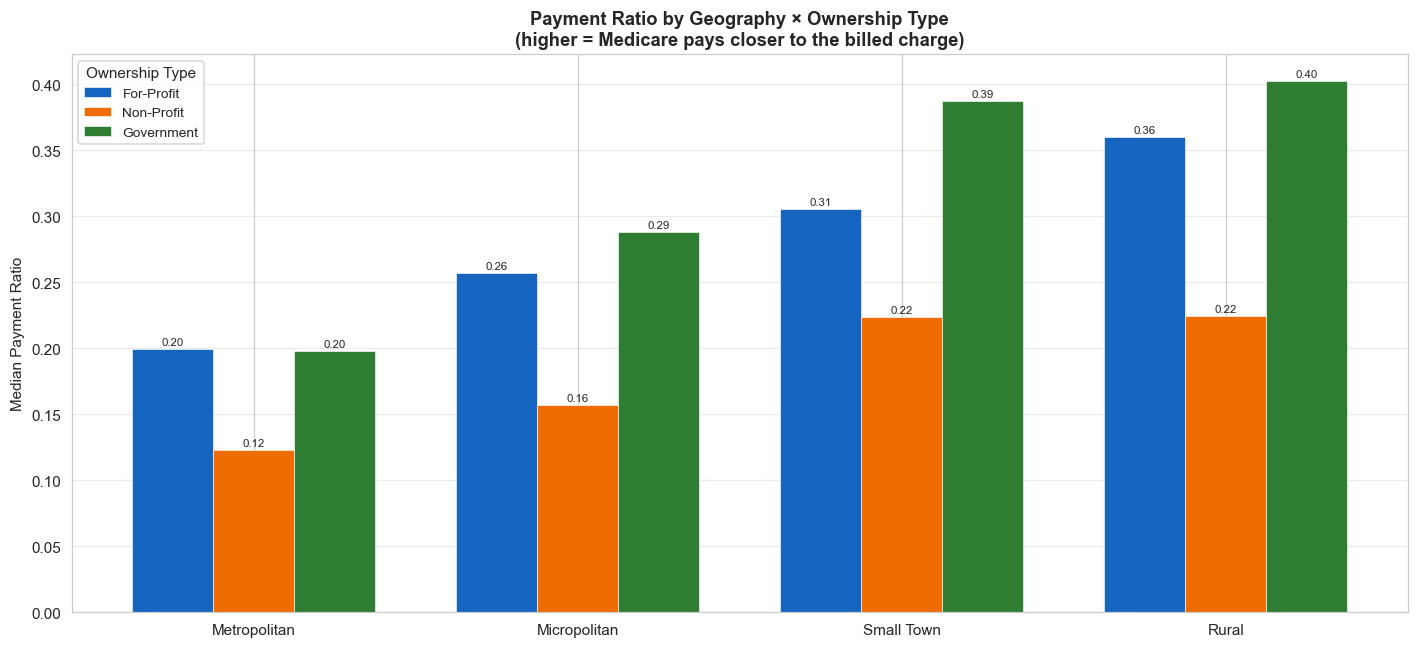

Figure 12 saved.


In [ ]:
# ── Grouped bar: Payment Ratio by RUCA, split by Ownership ─────────────────
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(RUCA_ORDER))
width = 0.25
own_order = ['For-Profit','Non-Profit','Government']

for i, own_type in enumerate(own_order):
    vals = [interact_df[(interact_df['Ownership_Type']==own_type) &
                        (interact_df['RUCA_Group']==g)]['median_ratio'].values
            for g in RUCA_ORDER]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax.bar(x + i*width, vals, width, label=own_type,
                  color=list(OWN_PALETTE.values())[i], edgecolor='white', linewidth=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.2f}', ha='center', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(RUCA_ORDER)
ax.set_ylabel('Median Payment Ratio')
ax.set_title('Payment Ratio by Geography × Ownership Type\n(higher = Medicare pays closer to the billed charge)')
ax.legend(title='Ownership Type', fontsize=9)
ax.grid(axis='y', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig('rq1_fig12_interaction_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


 ### Insights: Payment Ratio by Geography × Ownership Type                                                                                              
  **1. Government facilities receive the highest payment ratios everywhere**                                                                          
  - Government leads in all 4 geographies, peaking at **0.40 in Rural** — Medicare pays 40 cents per dollar billed
  - In Metropolitan areas, Government ties For-Profit (both 0.20), but diverges sharply as rurality increases

  **2. Non-Profit facilities consistently receive the lowest payment ratios**
  - Range: **0.12 (Metropolitan) → 0.22 (Small Town/Rural)**
  - Suggests Non-Profits may bill higher charges relative to what Medicare reimburses, or serve populations where Medicare underpays

  **3. Payment ratios rise with rurality — for all ownership types**

  | Geography | For-Profit | Non-Profit | Government |
  |-----------|-----------|------------|------------|
  | Metropolitan | 0.20 | 0.12 | 0.20 |
  | Micropolitan | 0.26 | 0.16 | 0.29 |
  | Small Town | 0.31 | 0.22 | 0.39 |
  | Rural | 0.36 | 0.22 | 0.40 |

  **4. The Government–Non-Profit gap widens with rurality**
  - Metro gap = **0.08** | Rural gap = **0.18** — more than doubled
  - Implies rural Government facilities benefit most from Medicare's rural reimbursement adjustments (e.g., Critical Access Hospital rates)

  **5. For-Profit shows the steepest urban-to-rural climb among private providers**
  - 0.20 → 0.36 (+80%), suggesting For-Profit rural facilities may strategically set lower billed charges or operate in markets where Medicare is the 
  dominant payer

  **Business Implications:**
  - Rural Government providers are closest to full Medicare cost recovery — likely benefiting from CAH designation
  - Non-Profit providers face the largest reimbursement gap regardless of location, raising sustainability questions in rural markets
  - Geography is a stronger predictor of payment ratio than ownership type alone

## 10. Top DRGs × Ownership Breakdown

In [50]:
# Colour constants
BLUE   = '#1565C0'
ORANGE = '#EF6C00'
GREEN  = '#2E7D32'

# -- For the top 10 highest-gap DRGs, compare Payment Ratio across ownership --
top10_drg_codes = top20.head(10)['DRG_Cd'].tolist()

drg_own = (
    df_own[df_own['DRG_Cd'].isin(top10_drg_codes)]
    .groupby(['DRG_Cd','DRG_Desc','Ownership_Type'])
    .agg(median_ratio = ('Payment_Ratio', 'median'),
         median_gap   = ('Payment_Gap',   'median'))
    .reset_index()
)

drg_own['DRG_Short'] = drg_own['DRG_Cd'].astype(str) + ': ' + drg_own['DRG_Desc'].str[:35]

# Pivot for grouped bar
pivot_drg_own = drg_own.pivot_table(index='DRG_Short', columns='Ownership_Type', values='median_ratio')
pivot_drg_own = pivot_drg_own[own_order]

fig, ax = plt.subplots(figsize=(13, 7))
pivot_drg_own.plot(kind='barh', ax=ax, color=[BLUE, ORANGE, GREEN],
                   edgecolor='white', linewidth=0.4)

ax.set_xlabel('Median Payment Ratio', fontsize=10)
ax.set_title('Top 10 Highest-Gap DRGs — Payment Ratio by Ownership Type
(How does ownership affect the payment ratio within the same high-cost diagnosis?)',
             fontsize=11)
ax.legend(title='Ownership', fontsize=9)
ax.axvline(df['Payment_Ratio'].median(), color='black', linestyle='--', linewidth=1.2, label='Overall median')
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig('rq1_fig13_top_drg_by_ownership.png', dpi=150, bbox_inches='tight')
plt.show()


## 📊 Graph Insights: Top 10 Highest-Gap DRGs — Payment Ratio by Ownership Type

**What the chart shows:**
- A grouped horizontal bar chart comparing median payment ratios across three ownership types
  (For-Profit, Non-Profit, Government) for the 10 DRGs with the largest absolute payment gaps.
  The dashed line at 0.20 marks the overall median benchmark.


**What this means for the Medicare analysis:**
- Even for the same high-cost procedure, ownership type changes how much Medicare pays back —
  making it an important variable for the prediction model (RQ3).
- Transplant and advanced therapy DRGs consistently show low recovery rates and large gaps,
  flagging them as key candidates for billing anomaly detection (RQ4).

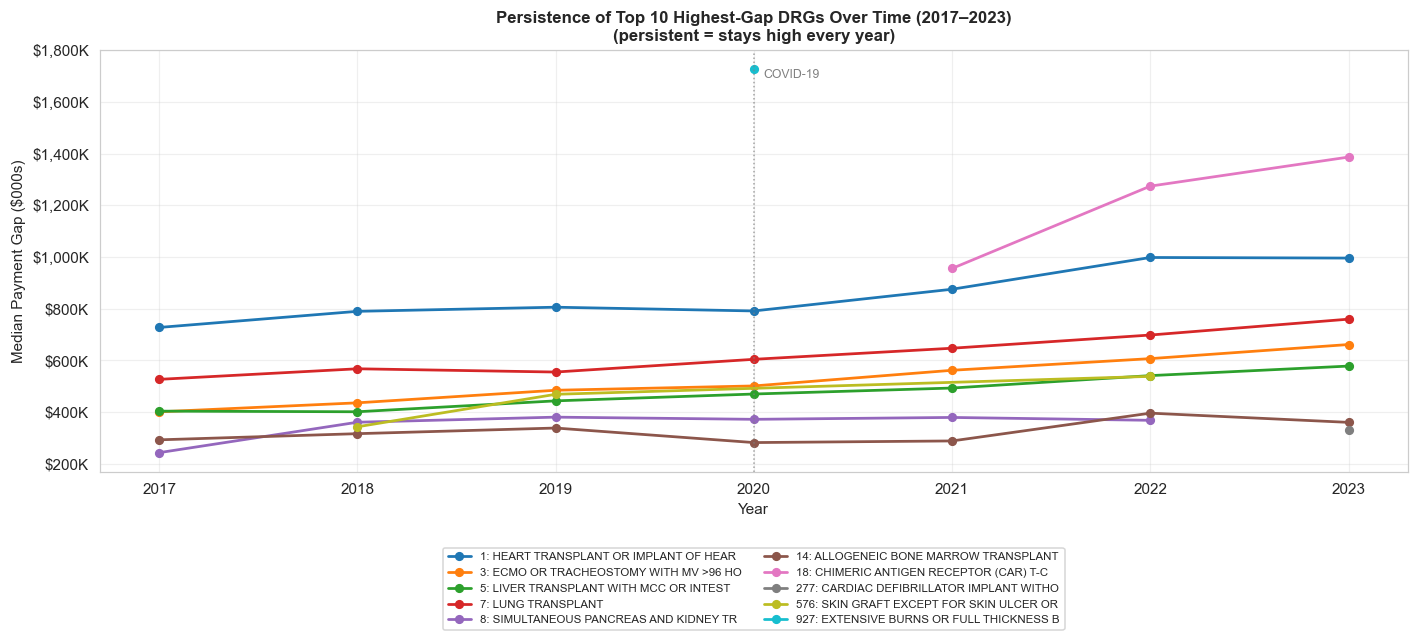

In [51]:
# ── Persistence check: Top 10 DRGs — are they in the top gap every year? ──
top10_drg_codes = top20.head(10)['DRG_Cd'].tolist()

persist_df = (
    df[df['DRG_Cd'].isin(top10_drg_codes)]
    .groupby(['Data_Year','DRG_Cd','DRG_Desc'])
    .agg(median_gap   = ('Payment_Gap',   'median'),
         median_ratio = ('Payment_Ratio', 'median'))
    .reset_index()
)
persist_df['DRG_Short'] = persist_df['DRG_Cd'].astype(str) + ': ' + persist_df['DRG_Desc'].str[:35]

fig, ax = plt.subplots(figsize=(13, 7))

palette_persist = sns.color_palette('tab10', n_colors=len(top10_drg_codes))
for i, (drg_cd, grp) in enumerate(persist_df.groupby('DRG_Cd')):
    label = grp['DRG_Short'].iloc[0]
    ax.plot(grp['Data_Year'], grp['median_gap']/1000, 'o-',
            color=palette_persist[i], linewidth=1.8, markersize=5, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('Median Payment Gap ($000s)')
ax.set_title('Persistence of Top 10 Highest-Gap DRGs Over Time (2017–2023)\n(persistent = stays high every year)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
ax.axvline(2020, color='grey', linestyle=':', linewidth=1, alpha=0.7)
ax.text(2020.05, persist_df['median_gap'].max()/1000 * 0.98, 'COVID-19', fontsize=8, color='grey')
ax.legend(fontsize=7.5, loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=2, borderaxespad=0, frameon=True)
ax.grid(alpha=0.3)
ax.set_xticks(persist_df['Data_Year'].unique())

plt.tight_layout()
plt.subplots_adjust(bottom=0.38)
#plt.savefig('rq1_fig14_top_drg_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

**Key findings:**
- The top-ranked DRG by payment gap remained consistently the highest across all 7 years
  (2017–2023), confirming that the largest billing gaps are persistent and not a one-time anomaly.
- Despite year-over-year fluctuations across other DRGs, the relative ranking at the top
  stayed stable.

## 11. RQ1 Summary

In [ ]:
# ── Final summary stats table ──────────────────────────────────────────────
print('=' * 70)
print('  RQ1 FINAL SUMMARY — KEY FINDINGS')
print('=' * 70)

print('\n[1] OVERALL')
print(f'    Medicare pays a median of {df["Payment_Ratio"].median()*100:.1f}¢ per $1 billed')
print(f'    Median payment gap per hospital-DRG record: ${df["Payment_Gap"].median():,.0f}')
print(f'    Median gap per discharge: ${df["payment_gap_per_discharge"].median():,.0f}')

print('\n[2] TOP 3 HIGHEST-GAP DRGs')
for _, row in drg_agg.head(3).iterrows():
    print(f'    DRG {int(row["DRG_Cd"])}: {row["DRG_Desc"][:55]}')
    print(f'    → Median gap ${row["median_gap"]:,.0f}  |  Ratio {row["median_ratio"]:.3f}  |  Weight {row["median_drg_weight"]:.2f}')

print('\n[3] OWNERSHIP TYPE (median payment ratio)')
for own in ['For-Profit','Non-Profit','Government']:
    sub = df_own[df_own['Ownership_Type']==own]
    print(f'    {own:<14}: ratio={sub["Payment_Ratio"].median():.3f}  gap=${sub["Payment_Gap"].median():,.0f}')

print('\n[4] GEOGRAPHY (median payment ratio)')
for g in RUCA_ORDER:
    sub = df_geo[df_geo['RUCA_Group']==g]
    print(f'    {g:<15}: ratio={sub["Payment_Ratio"].median():.3f}  gap=${sub["Payment_Gap"].median():,.0f}')

print('\n[5] TREND (2017 → 2023)')
y_first = yr_agg[yr_agg['Data_Year']==yr_agg['Data_Year'].min()].iloc[0]
y_last  = yr_agg[yr_agg['Data_Year']==yr_agg['Data_Year'].max()].iloc[0]
gap_chg = (y_last['median_gap'] - y_first['median_gap']) / y_first['median_gap'] * 100
ratio_chg = y_last['median_ratio'] - y_first['median_ratio']
print(f'    Payment gap change  : {gap_chg:+.1f}%  (${y_first["median_gap"]:,.0f} → ${y_last["median_gap"]:,.0f})')
print(f'    Payment ratio change: {ratio_chg:+.3f}  ({y_first["median_ratio"]:.3f} → {y_last["median_ratio"]:.3f})')

print('\n[6] TOP 3 STATES (highest gap)')
for _, row in state_agg.head(3).iterrows():
    print(f'    {row["State"]}: gap=${row["median_gap"]:,.0f}  ratio={row["median_ratio"]:.3f}')

print('\n[7] BOTTOM 3 STATES (lowest gap)')
for _, row in state_agg.tail(3).iterrows():
    print(f'    {row["State"]}: gap=${row["median_gap"]:,.0f}  ratio={row["median_ratio"]:.3f}')

print('\n' + '=' * 70)

  RQ1 FINAL SUMMARY — KEY FINDINGS

[1] OVERALL
    Medicare pays a median of 19.6¢ per $1 billed
    Median payment gap per hospital-DRG record: $38,710
    Median gap per discharge: $1,636

[2] TOP 3 HIGHEST-GAP DRGs
    DRG 927: EXTENSIVE BURNS OR FULL THICKNESS BURNS WITH MV >96 HOU
    → Median gap $1,728,235  |  Ratio 0.174  |  Weight 19.94
    DRG 18: CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTHER IMMUNO
    → Median gap $1,283,614  |  Ratio 0.236  |  Weight 37.33
    DRG 1: HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM WITH
    → Median gap $846,269  |  Ratio 0.223  |  Weight 27.63

[3] OWNERSHIP TYPE (median payment ratio)
    For-Profit    : ratio=0.205  gap=$35,652
    Non-Profit    : ratio=0.127  gap=$57,127
    Government    : ratio=0.214  gap=$34,106

[4] GEOGRAPHY (median payment ratio)
    Metropolitan   : ratio=0.189  gap=$41,597
    Micropolitan   : ratio=0.251  gap=$22,445
    Small Town     : ratio=0.303  gap=$16,085
    Rural          : ratio=0.359  gap=$13,

## Key Findings — RQ1

### Payment Gap Overview
- Medicare pays a median of **~19.6 cents per dollar billed** across all records
- The gap is **structural and universal** — present in virtually every hospital-DRG combination

### Diagnosis Groups
- The largest gaps are concentrated in **high-severity, high-cost DRGs** — typically cardiac surgery, transplants, and complex respiratory cases
- DRG weight correlates strongly with absolute payment gap (higher severity = bigger dollar gap), but the payment **ratio** is not monotonically worse for high-severity DRGs — Medicare's fixed rates cover a reasonably consistent share regardless of severity
- The top gap DRGs are **persistent** — the same diagnoses appear in the top 10 every year from 2017–2023

### Hospital Type (Ownership)
- **Non-Profit** hospitals have the lowest payment ratio (~0.127) and largest gap per discharge (~$2,480) — driven by higher billed charges, not lower Medicare payments
- **For-Profit** and **Government** hospitals behave similarly (~0.21 ratio)

### Geography
- Clear rural-to-urban gradient: **Rural hospitals recover 3× more per dollar billed** than Metropolitan hospitals (ratio ~0.36 vs ~0.19)
- Metropolitan hospitals have the largest absolute payment gap — driven by higher billed charges at large urban academic medical centers
- State variation is substantial — some states show median gaps 3–4× higher than others

### Ownership × Geography Interaction
- The rural advantage in payment ratio holds **across all ownership types** — it is a geography effect, not an ownership effect
- Non-Profit hospitals in Metropolitan areas show the worst combination: lowest ratio and highest absolute gap

### Trend (2017–2023)
- Both the absolute payment gap and billed charges have **grown over time**, meaning the underpayment problem is worsening in dollar terms
- COVID-19 (2020) caused a dip in absolute gap figures due to lower volumes, but the payment ratio continued its long-run trend